# Dataset for Scientific Paper

### Libraries

In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import scipy.stats
import plotly
import csv
import random
from scipy.stats import ks_2samp
import polars as pl

In [14]:
print("Polars version:", pl.__version__)

Polars version: 1.8.2


In [15]:
print("Numpy version:", np.__version__)

Numpy version: 1.26.4


### Dataset

In [17]:
pl.Config.set_tbl_rows(200)

polars.config.Config

In [18]:
import os
print(os.getcwd())

C:\Users\Samsung\Documents\DOTTORATO\GitHub\NSE_Lombardy


Firstly we upload the dataset.

In [23]:
full_data = pl.read_csv('C:/Users/Samsung/Documents/THESIS/Luca/dataset_utilizzabile.csv')

full_data.shape

(985788, 105)

#### Integration of TSH, Diagnosis and Category

In [20]:
tsh = pl.read_csv('TSH.csv')
tsh

NTSH,SampleBarcode,SamTimeCollected
str,str,str
"""2,98073554390887""","""20LD042587""","""2021-12-21"""
"""0,787225961633919""","""20LD050321""","""2021-12-28"""
"""25,5033800140779""","""20LD810743""","""2021-12-20"""
"""3,30434590191451""","""20LD811192""","""2021-12-17"""
"""1,09726795806592""","""20LD811194""","""2021-12-16"""
"""0,639845726824699""","""20LD811195""","""2021-12-16"""
"""1,05596437725352""","""20LD811196""","""2021-12-17"""
"""1,43407485552288""","""20LD811197""","""2021-12-17"""
"""2,50485132033995""","""20LD811198""","""2021-12-17"""


In [21]:
tsh['SampleBarcode'].unique().shape

(985783,)

In [22]:
tsh.shape

(985783, 3)

In [26]:
full_data = full_data.join(tsh, on= ["SampleBarcode"], how="left")
full_data.shape

(985788, 107)

In [27]:
full_data.columns

['ASATotal',
 'Ala',
 'Allele 1',
 'Arg',
 'Cit',
 'Glu',
 'Gly',
 'Leu\\Ile\\Pro-OH',
 'Orn',
 'MET',
 'PHE',
 'TYR',
 'HCYS',
 'Pro',
 'Val',
 'BTD',
 'C0',
 'C3',
 'C4OH\\C3DC',
 'C4',
 'C5OH\\C4DC',
 'C5',
 'C5:1',
 'C5DC\\C6OH',
 'C6',
 'C6DC',
 'C8',
 'C8:1',
 'C10',
 'C10:1',
 'C10:2',
 'C12',
 'C12:1',
 'C14',
 'C14:1',
 'C14:2',
 'C14-OH',
 'C16',
 'C16:1',
 'C16-OH',
 'C16:1-OH',
 'C18',
 'C18:1',
 'C18:2',
 'C18-OH',
 'C18:1-OH',
 'C18:2OH',
 'C20',
 'C22',
 'C24',
 'C26',
 'SA',
 'ADO',
 'D-ADO',
 'C20:0-LPC',
 'C22:0-LPC',
 'C24:0-LPC',
 'C26:0-LPC',
 'IRT-GSP',
 'TGAL',
 'MMA',
 'EMA',
 'GA',
 '2OH GA',
 '3OH GA',
 '3OH PA',
 'MCA',
 'OROTICO',
 'PIVA',
 '2MBC',
 'c4-b',
 'c4-i',
 'DateOfBirth',
 'Sex',
 'City',
 'Sampling',
 'GestationalAge',
 'Etnicity',
 'SampleBarcode',
 'SampleQuality',
 'SamTimeCollected',
 'SamTimeReceived',
 'Weight',
 'AntibioticsBaby',
 'AntibioticsMother',
 'Meconium',
 'CortisoneBaby',
 'CortisoneMother',
 'TyroidMother',
 'Premature',
 'TooYo

In [28]:
full_data = full_data.drop('SamTimeCollected_right')

We sorted all the observations from the variable indicating the time of withdrawal.

In [30]:
full_data = full_data.sort('SamTimeCollected')

Then we uploaded the file with the diagnosis and rename the variable to be used for the join with the same name of the one in the main dataset.

In [32]:
dis = pl.read_excel('C:/Users/Samsung/Documents/THESIS/Per Gloria.xlsx')
dis = dis.rename({"CODIE NEONATO": "SampleBarcode"})
dis.head()

SampleBarcode,DIAGNOSI,CATEGORIA
str,str,str
"""1600072855""","""MTHFR""","""AA"""
"""1600096585""","""CBS""","""AA"""
"""19LD032896""","""CBS""","""AA"""
"""19LD011001""","""CBS""","""AA"""
"""1500121493""","""PHE""","""AA"""


In [33]:
dis['SampleBarcode']

SampleBarcode
str
"""1600072855"""
"""1600096585"""
"""19LD032896"""
"""19LD011001"""
"""1500121493"""
"""1500186270"""
"""1500123770"""
"""1620230426"""
"""1620399031"""


In [34]:
dis['DIAGNOSI'].unique()

DIAGNOSI
str
"""ASA"""
"""CIT1"""
"""CblD"""
"""CblA"""
"""CBS"""
"""PKU"""
"""HPA"""
"""VLCAD"""
"""CPT2"""


CIT 1 and CIT1 represent the same disease. The number of unique diseases appearing in the dataset is 29. \
The features with low consistency and low quality are deleted.

In [36]:
dis = dis.with_columns([pl.col("DIAGNOSI").str.replace(r"CIT 1", "CIT1").alias("DIAGNOSI")])

In [38]:
dis['CATEGORIA'].value_counts()

CATEGORIA,count
str,u32
"""FAO""",35
"""SC""",26
"""UCD""",12
"""AO""",26
"""AA""",110


'SC' is not a category. It is necessary to imput the right category for each observation with 'SC' as category.

In [40]:
dis = dis.with_columns([pl.when(pl.col("DIAGNOSI") == "IBG").then(pl.col("CATEGORIA").str.replace(r"SC", "AO")).otherwise(pl.col("CATEGORIA")).alias("CATEGORIA")])


In [41]:
dis = dis.with_columns([pl.when(pl.col("DIAGNOSI") == "TYR3").then(pl.col("CATEGORIA").str.replace(r"SC", "AA")).otherwise(pl.col("CATEGORIA")).alias("CATEGORIA")])
dis = dis.with_columns([pl.when(pl.col("DIAGNOSI") == "SCAD").then(pl.col("CATEGORIA").str.replace(r"SC", "FAO")).otherwise(pl.col("CATEGORIA")).alias("CATEGORIA")])
dis = dis.with_columns([pl.when(pl.col("DIAGNOSI") == "CPS1").then(pl.col("CATEGORIA").str.replace(r"SC", "AA")).otherwise(pl.col("CATEGORIA")).alias("CATEGORIA")])
dis = dis.with_columns([pl.when(pl.col("DIAGNOSI") == "3MCC").then(pl.col("CATEGORIA").str.replace(r"SC", "AO")).otherwise(pl.col("CATEGORIA")).alias("CATEGORIA")])


In [42]:
dis['CATEGORIA'].value_counts()

CATEGORIA,count
str,u32
"""AO""",33
"""AA""",112
"""UCD""",12
"""FAO""",52


In [43]:
dis = dis.rename({"DIAGNOSI": "Diagnosis"})
dis = dis.rename({"CATEGORIA": "Category"})

In [46]:
babies_d = full_data.join(dis, on="SampleBarcode", how="left")
babies_d

ASATotal,Ala,Arg,Cit,Glu,Gly,Leu\Ile\Pro-OH,Orn,MET,PHE,TYR,HCYS,Pro,Val,BTD,C0,C3,C4OH\C3DC,C4,C5OH\C4DC,C5,C5:1,C5DC\C6OH,C6,C6DC,C8,C8:1,C10,C10:1,C10:2,C12,C12:1,C14,C14:1,C14:2,C14-OH,C16,…,MCA,OROTICO,PIVA,2MBC,c4-b,c4-i,DateOfBirth,Sex,GestationalAge,SampleBarcode,SamTimeCollected,SamTimeReceived,Weight,AntibioticsBaby,AntibioticsMother,Meconium,CortisoneBaby,CortisoneMother,TyroidMother,Premature,TooYoung,BabyFed,HUFeed,MIXFeed,ARTFeed,TPNFeed,ENFeed,TPNCARNFeed,TPNMCTFeed,Hospital,BirthMethod,BIS,Twins,id,NTSH,Diagnosis,Category
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,str,str,i64,str,str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,str,str,f64,f64,i64,str,str,str
null,230.42,12.66,13.8,null,464.47,141.35,88.39,22.11,40.28,182.62,null,209.76,118.04,null,7.72,1.79,0.41,0.12,0.21,0.07,0.01,0.14,0.06,0.12,0.06,0.01,0.07,0.02,0.0,0.11,0.07,0.21,0.11,0.01,0.02,3.74,…,null,null,null,null,null,null,"""2012-12-03""","""M""",39,"""1220252477""",null,"""2012-12-11""",3470,0.0,null,0.0,0.0,null,0.0,0.0,0.0,1.0,1,0,0,0,0,0,0,"""A.O. Ospedali Riuniti BG Giova…",null,null,0.0,798669216849525467,"""1,18036056423254""",null,null
null,228.77,11.44,7.49,null,356.49,127.22,88.62,22.21,50.33,205.83,null,159.29,117.29,null,16.99,2.26,0.33,0.22,0.2,0.09,0.01,0.12,0.04,0.08,0.05,0.08,0.07,0.06,0.01,0.09,0.06,0.19,0.1,0.02,0.02,3.01,…,null,null,null,null,null,null,"""2012-01-07""","""M""",39,"""1221042695""","""2012-01-11""","""2013-01-14""",3440,0.0,null,0.0,0.0,null,0.0,0.0,0.0,1.0,0,1,0,0,0,0,0,"""Ospedale S. Giuseppe S.p.A.""",null,null,0.0,-3045315683506551317,"""1,52760940507699""",null,null
null,248.25,10.12,13.88,null,431.12,152.21,91.55,31.31,69.13,66.96,null,160.16,119.88,337.929074,26.53,2.15,0.23,0.26,0.4,0.16,0.01,0.18,0.08,0.13,0.07,0.07,0.09,0.07,0.01,0.09,0.07,0.23,0.15,0.03,0.02,4.39,…,null,null,null,null,null,null,"""2012-02-22""","""F""",40,"""21ld021284""","""2012-02-24""","""2021-02-24 12:38:02.410""",3350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,1,0,0,0,0,"""Ospedale San Pio X Rep. NIDO""",null,null,null,5655596528266926376,"""1,22157734314711""",null,null
null,0.0,0.0,0.0,null,0.0,0.0,0.0,0.0,622.27,44.46,null,0.0,0.0,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,null,null,null,null,null,null,"""2012-04-27""","""F""",37,"""2012001723""","""2012-04-30""","""2012-05-09""",2560,0.0,null,0.0,0.0,null,0.0,0.0,0.0,1.0,0,1,0,0,0,0,0,"""A.O. San Gerardo REP. NIDO""",null,null,0.0,8999108248963732586,"""1,95616855699912""",null,null
null,254.93,2.25,12.82,null,612.23,157.09,105.43,22.29,57.01,87.42,null,196.64,128.89,null,19.25,1.91,0.14,0.08,0.28,0.04,0.0,0.19,0.03,0.11,0.07,0.03,0.08,0.03,0.0,0.1,0.1,0.22,0.11,0.02,0.02,3.01,…,null,null,null,null,null,null,"""2012-05-05""","""M""",38,"""2012001716""","""2012-05-06""","""2012-05-08""",2940,0.0,null,null,null,null,0.0,0.0,1.0,1.0,1,0,0,0,0,0,0,"""Ospedale V. Buzzi Rep. Nido""",null,null,0.0,-2062742519198422210,"""1,40038720690411""",null,null
null,0.0,0.0,0.0,null,0.0,0.0,0.0,0.0,76.2,187.95,null,0.0,0.0,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,null,null,null,null,null,null,"""2012-05-04""","""F""",36,"""2012001921""","""2012-05-06""","""2012-05-09""",2680,0.0,null,null,null,null,0.0,0.0,0.0,1.0,1,0,0,0,0,0,0,"""A.O. Ospedali Riuniti BG Giova…",null,null,0.0,3467001463626499211,"""1,84873889515083""",null,null
null,204.82,4.27,17.81,null,640.91,117.9,90.87,24.22,53.69,70.25,null,159.32,101.37,null,11.78,1.77,0.13,0.09,0.17,0.06,0.01,0.14,0.05,0.08,0.07,0.02,0.07,0.02,0.0,0.16,0.1,0.31,0.17,0.03,0.03,4.95,…,null,null,null,null,null,null,"""2012-05-05""","""M""",39,"""2012001624""","""2012-05-07""","""2012-05-08""",3735,0.0,null,null,null,null,0.0,0.0,0.0,1.0,1,0,0,0,0,0,0,"""Ospedale V. Buzzi Rep. Nido""",null,null,0.0,5

We then performed a join to merge the data.

The babies with a positive diagnosis are: 

In [48]:
babies_d.filter(pl.col('Diagnosis') != 'SANO')

ASATotal,Ala,Arg,Cit,Glu,Gly,Leu\Ile\Pro-OH,Orn,MET,PHE,TYR,HCYS,Pro,Val,BTD,C0,C3,C4OH\C3DC,C4,C5OH\C4DC,C5,C5:1,C5DC\C6OH,C6,C6DC,C8,C8:1,C10,C10:1,C10:2,C12,C12:1,C14,C14:1,C14:2,C14-OH,C16,…,MCA,OROTICO,PIVA,2MBC,c4-b,c4-i,DateOfBirth,Sex,GestationalAge,SampleBarcode,SamTimeCollected,SamTimeReceived,Weight,AntibioticsBaby,AntibioticsMother,Meconium,CortisoneBaby,CortisoneMother,TyroidMother,Premature,TooYoung,BabyFed,HUFeed,MIXFeed,ARTFeed,TPNFeed,ENFeed,TPNCARNFeed,TPNMCTFeed,Hospital,BirthMethod,BIS,Twins,id,NTSH,Diagnosis,Category
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,str,str,i64,str,str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,str,str,f64,f64,i64,str,str,str
null,179.59,7.44,13.41,null,217.25,121.56,65.66,17.49,221.39,62.85,null,121.69,148.81,null,10.79,1.28,0.12,0.31,0.17,0.06,0.01,0.08,0.03,0.12,0.06,0.02,0.08,0.04,0.0,0.1,0.08,0.16,0.09,0.01,0.01,2.292,…,null,null,null,null,null,null,"""2016-01-05""","""M""",40,"""1500121493""","""2016-01-08""","""2016-01-11""",3510,0.0,null,0.0,0.0,null,0.0,0.0,0.0,null,1,0,0,0,0,0,0,"""Ospedale di Garbagnate Rep. N…","""Naturale""",null,0.0,-4099876545650839355,"""3,2582582550382""","""PHE""","""AA"""
null,461.74,10.04,15.39,null,365.06,113.57,86.88,32.02,104.15,55.76,null,210.61,99.97,null,32.73,2.31,0.1,0.27,0.25,0.14,0.01,0.11,0.04,0.08,0.04,0.05,0.04,0.04,0.0,0.07,0.04,0.27,0.06,0.02,0.01,3.88,…,null,null,null,null,null,null,"""2016-01-12""","""F""",40,"""1500186270""","""2016-01-14""","""2016-01-15""",3040,0.0,null,0.0,0.0,null,0.0,0.0,0.0,null,0,0,1,0,0,0,0,"""Ospedale Civile Manerbio Repar…","""Naturale""",null,0.0,-132569622806364478,"""7,59""","""PHE""","""AA"""
null,133.96,3.92,11.07,null,237.63,130.79,67.11,19.69,245.53,100.42,null,129.96,115.41,null,19.53,1.81,0.31,0.3,0.16,0.12,0.01,0.24,0.05,0.13,0.05,0.04,0.09,0.06,0.0,0.1,0.1,0.27,0.11,0.02,0.02,4.02,…,null,null,null,null,null,null,"""2016-02-22""","""M""",39,"""1500123770""","""2016-02-25""","""2016-02-26""",3175,0.0,null,0.0,0.0,null,0.0,0.0,0.0,null,1,0,0,0,0,0,0,"""Ospedale San Raffaele Rep. NID…","""Cesareo""",null,0.0,-6313351488770467286,"""1,19980240696504""","""PHE""","""AA"""
null,208.07,4.67,13.54,null,136.67,113.73,109.17,16.12,135.57,68.86,null,121.21,116.43,null,14.92,1.69,0.12,0.22,0.18,0.1,0.01,0.08,0.05,0.11,0.06,0.01,0.1,0.05,0.0,0.1,0.07,0.17,0.08,0.01,0.01,2.54,…,null,null,null,null,null,null,"""2016-05-09""","""F""",40,"""1620230426""","""2016-05-12""","""2016-05-13""",3550,0.0,null,0.0,0.0,null,0.0,0.0,0.0,null,0,1,0,0,0,0,0,"""Ospedale V. Emanuele III Carat…","""Naturale""",null,0.0,2740625558724801853,"""2,50395897664433""","""PHE""","""AA"""
null,237.28,14.34,21.84,null,417.31,199.36,149.71,40.77,69.41,160.63,null,251.42,167.07,null,24.46,1.48,0.27,0.27,0.22,0.18,0.03,0.12,0.04,0.29,0.07,0.05,0.13,0.08,0.004,0.54,0.19,2.22,2.94,0.23,0.07,6.32,…,null,null,null,null,null,null,"""2016-05-12""","""F""",37,"""1620038237""","""2016-05-16""","""2016-05-16""",3020,0.0,null,0.0,0.0,null,0.0,0.0,0.0,null,0,1,0,0,0,0,0,"""Ospedale Città di Sesto S.Giov…","""Cesareo""",null,0.0,6137216806024541851,"""2,99116003567312""","""VLCAD""","""FAO"""
null,239.43,15.58,19.39,null,277.72,154.96,88.47,16.89,207.13,82.44,null,151.32,187.88,null,15.61,3.23,0.41,0.29,0.27,0.11,0.01,0.21,0.05,0.12,0.07,0.04,0.12,0.05,0.0,0.25,0.26,0.35,0.31,0.03,0.04,5.79,…,null,null,null,null,null,null,"""2016-06-24""","""F""",39,"""1620399031""","""2016-06-27""","""2016-06-27""",3705,0.0,null,0.0,0.0,null,0.0,0.0,0.0,null,1,0,0,0,0,0,0,"""F.ne Cà Granda OM Policlinico …","""Cesareo""",null,0.0,-5866174612931821952,"""2,67478103227476""","""PHE""","""AA"""
null,309.91,17.11,12.11,null,548.84,152.44,206.83,19.12,154.27,78.66,null,177.29,118.12,null,46.91,3.15,0.15,0.69,0.29,0.15,0.03,0.08,0.03,0.09,0.09,0.03,0.06,0.04,0.0,0.13,0.03,0.38,0.11,0.03,0.02,5.03,…,null,null,nu

We filled the missing values of the DIAGNOSI with the value 'SANO' which means healthy.

In [50]:
babies_d = babies_d.with_columns(replaced=pl.col("Diagnosis").replace(None, 'HEALTHY'))
babies_d = babies_d.drop('Diagnosis')
babies_d = babies_d.rename({"replaced": "Diagnosis"})
babies_d.group_by('Diagnosis').len()

Diagnosis,len
str,u32
"""TFP EXITUS""",3
"""ASA""",1
"""CblA""",1
"""CIT1""",9
"""HEALTHY""",985590
"""BKT""",1
"""ARG""",1
"""IBG""",3
"""IVA""",3


#### Deleting the features that are no usefull 

In [37]:
full_data = full_data.drop(['Allele 1','City', 'Etnicity', 'Sampling', 'AnswerIX', 'SampleQuality' ])

In [45]:
full_data.shape

(985788, 100)

In [340]:
babies_d.columns

['ASATotal',
 'Ala',
 'Arg',
 'Cit',
 'Glu',
 'Gly',
 'Leu\\Ile\\Pro-OH',
 'Orn',
 'MET',
 'PHE',
 'TYR',
 'HCYS',
 'Pro',
 'Val',
 'BTD',
 'C0',
 'C3',
 'C4OH\\C3DC',
 'C4',
 'C5OH\\C4DC',
 'C5',
 'C5:1',
 'C5DC\\C6OH',
 'C6',
 'C6DC',
 'C8',
 'C8:1',
 'C10',
 'C10:1',
 'C10:2',
 'C12',
 'C12:1',
 'C14',
 'C14:1',
 'C14:2',
 'C14-OH',
 'C16',
 'C16:1',
 'C16-OH',
 'C16:1-OH',
 'C18',
 'C18:1',
 'C18:2',
 'C18-OH',
 'C18:1-OH',
 'C18:2OH',
 'C20',
 'C22',
 'C24',
 'C26',
 'SA',
 'ADO',
 'D-ADO',
 'C20:0-LPC',
 'C22:0-LPC',
 'C24:0-LPC',
 'C26:0-LPC',
 'IRT-GSP',
 'TGAL',
 'MMA',
 'EMA',
 'GA',
 '2OH GA',
 '3OH GA',
 '3OH PA',
 'MCA',
 'OROTICO',
 'PIVA',
 '2MBC',
 'c4-b',
 'c4-i',
 'DateOfBirth',
 'Sex',
 'GestationalAge',
 'SampleBarcode',
 'SamDateCollected',
 'SamDateReceived',
 'Weight',
 'AntibioticsBaby',
 'AntibioticsMother',
 'Meconium',
 'CortisoneBaby',
 'CortisoneMother',
 'TyroidMother',
 'Premature',
 'TooYoung',
 'BabyFed',
 'HUFeed',
 'MIXFeed',
 'ARTFeed',
 'TPNFeed',
 

#### Fixing the types

In [53]:
babies_d = babies_d.with_columns(
    pl.col("NTSH")
    .cast(pl.Utf8)
    .str.replace_all(",", ".")  
    .cast(pl.Float64)
)


In [54]:
for col in babies_d.columns:
    print('colonna',col,'di tipo', babies_d[col].dtype)

colonna ASATotal di tipo Float64
colonna Ala di tipo Float64
colonna Arg di tipo Float64
colonna Cit di tipo Float64
colonna Glu di tipo Float64
colonna Gly di tipo Float64
colonna Leu\Ile\Pro-OH di tipo Float64
colonna Orn di tipo Float64
colonna MET di tipo Float64
colonna PHE di tipo Float64
colonna TYR di tipo Float64
colonna HCYS di tipo Float64
colonna Pro di tipo Float64
colonna Val di tipo Float64
colonna BTD di tipo Float64
colonna C0 di tipo Float64
colonna C3 di tipo Float64
colonna C4OH\C3DC di tipo Float64
colonna C4 di tipo Float64
colonna C5OH\C4DC di tipo Float64
colonna C5 di tipo Float64
colonna C5:1 di tipo Float64
colonna C5DC\C6OH di tipo Float64
colonna C6 di tipo Float64
colonna C6DC di tipo Float64
colonna C8 di tipo Float64
colonna C8:1 di tipo Float64
colonna C10 di tipo Float64
colonna C10:1 di tipo Float64
colonna C10:2 di tipo Float64
colonna C12 di tipo Float64
colonna C12:1 di tipo Float64
colonna C14 di tipo Float64
colonna C14:1 di tipo Float64
colonna 

In [55]:
babies_d = babies_d.with_columns(pl.col("Weight").cast(pl.Float64))
babies_d = babies_d.with_columns(pl.col('IRT-GSP').cast(pl.Float64))

In [56]:
babies_d = babies_d.with_columns(babies_d["CortisoneMother"].fill_null("0"))
babies_d = babies_d.with_columns(babies_d["AntibioticsMother"].fill_null("0"))
babies_d = babies_d.with_columns(babies_d["Meconium"].fill_null("0"))
babies_d = babies_d.with_columns(babies_d["TyroidMother"].fill_null("0"))
babies_d = babies_d.with_columns(babies_d["BIS"].fill_null("0"))
babies_d = babies_d.with_columns(babies_d["BabyFed"].fill_null("0"))
babies_d = babies_d.with_columns(babies_d["Twins"].fill_null("0"))
babies_d = babies_d.with_columns(babies_d["CortisoneBaby"].fill_null("0"))
babies_d = babies_d.with_columns(babies_d["AntibioticsBaby"].fill_null("0"))

In [57]:
babies_d = babies_d.with_columns([pl.col("CortisoneMother").cast(pl.Float64).cast(pl.Int8),
    pl.col("AntibioticsMother").cast(pl.Float64).cast(pl.Int8),
    pl.col("Meconium").cast(pl.Float64).cast(pl.Int8),
    pl.col("TyroidMother").cast(pl.Float64).cast(pl.Int8), 
    pl.col("BIS").cast(pl.Float64).cast(pl.Int8), 
    pl.col("BabyFed").cast(pl.Float64).cast(pl.Int8),
    pl.col("Twins").cast(pl.Float64).cast(pl.Int8),
    pl.col("CortisoneBaby").cast(pl.Float64).cast(pl.Int8),
    pl.col("AntibioticsBaby").cast(pl.Float64).cast(pl.Int8),
    pl.col("MIXFeed").cast(pl.Float64).cast(pl.Int8),
    pl.col("ARTFeed").cast(pl.Float64).cast(pl.Int8),
    pl.col("TPNFeed").cast(pl.Float64).cast(pl.Int8),
    pl.col("ENFeed").cast(pl.Float64).cast(pl.Int8), 
    pl.col("TPNCARNFeed").cast(pl.Float64).cast(pl.Int8),
    pl.col("TPNMCTFeed").cast(pl.Float64).cast(pl.Int8)
])

In [58]:
babies_d = babies_d.with_columns(pl.col("DateOfBirth").str.to_date("%Y-%m-%d"))
babies_d = babies_d.with_columns(pl.col("SamTimeCollected").str.replace("T00:00:00.000000", "").alias("SamTimeCollected"))
babies_d = babies_d.with_columns(pl.col("SamTimeCollected").str.to_date("%Y-%m-%d"))

In [59]:
babies_d = babies_d.rename({"SamTimeCollected": "SamDateCollected"})

In [60]:
babies_d['SamTimeReceived'].unique()

SamTimeReceived
str
"""2021-07-09 14:44:00.893"""
"""2018-09-07 14:38:38.350"""
"""2021-05-03 15:30:41.700"""
"""2018-07-06 11:54:00.493"""
"""2019-11-11 12:29:30.600"""
"""2020-12-16 12:04:35.547"""
"""2018-11-13 14:40:51.670"""
"""2018-07-27 11:40:51.387"""
"""2012-12-17"""


In [61]:
babies_d = babies_d.with_columns(
    pl.col("SamTimeReceived")
    .str.strptime(pl.Datetime, format= None, strict=True)
    .cast(pl.Date) 
)


In [62]:
babies_d = babies_d.rename({"SamTimeReceived": "SamDateReceived"})

In [86]:
babies_def = babies_def.with_columns(pl.col("ASATotal").cast(pl.Float64))
babies_def = babies_def.with_columns(pl.col("Glu").cast(pl.Float64))
babies_def = babies_def.with_columns(pl.col("C18:2OH").cast(pl.Float64))
babies_def = babies_def.with_columns(pl.col("C20").cast(pl.Float64))
babies_def = babies_def.with_columns(pl.col("C20").cast(pl.Float64))
babies_def = babies_def.with_columns(pl.col("C22").cast(pl.Float64))
babies_def = babies_def.with_columns(pl.col("C24").cast(pl.Float64))
babies_def = babies_def.with_columns(pl.col("C26").cast(pl.Float64))
babies_def = babies_def.with_columns(pl.col("ADO").cast(pl.Float64))
babies_def = babies_def.with_columns(pl.col("D-ADO").cast(pl.Float64))
babies_def = babies_def.with_columns(pl.col("C20:0-LPC").cast(pl.Float64))
babies_def = babies_def.with_columns(pl.col("C22:0-LPC").cast(pl.Float64))
babies_def = babies_def.with_columns(pl.col("C24:0-LPC").cast(pl.Float64))
babies_def = babies_def.with_columns(pl.col("C26:0-LPC").cast(pl.Float64))
babies_def = babies_def.with_columns(pl.col("IRT-GSP").cast(pl.Float64))
babies_def = babies_def.with_columns(pl.col("EMA").cast(pl.Float64))
babies_def = babies_def.with_columns(pl.col("2OH GA").cast(pl.Float64))
babies_def = babies_def.with_columns(pl.col("3OH GA").cast(pl.Float64))
babies_def = babies_def.with_columns(pl.col("3OH PA").cast(pl.Float64))
babies_def = babies_def.with_columns(pl.col("MCA").cast(pl.Float64))
babies_def = babies_def.with_columns(pl.col("OROTICO").cast(pl.Float64))
babies_def = babies_def.with_columns(pl.col("PIVA").cast(pl.Float64))
babies_def = babies_def.with_columns(pl.col("2MBC").cast(pl.Float64))
babies_def = babies_def.with_columns(pl.col("c4-b").cast(pl.Float64))
babies_def = babies_def.with_columns(pl.col("c4-i").cast(pl.Float64))
babies_def = babies_def.with_columns(pl.col("HCYS").cast(pl.Float64))

#### GestationalAge
- Are TooYoung all with less than 37 week of gestationalage?

In [64]:
babies_d = babies_d.with_columns(pl.when(pl.col('GestationalAge') < 37).then(1).otherwise(0).alias('Premature'))

In [65]:
babies_d.filter((pl.col('Premature') == 1) & (pl.col('GestationalAge') < 37))

ASATotal,Ala,Arg,Cit,Glu,Gly,Leu\Ile\Pro-OH,Orn,MET,PHE,TYR,HCYS,Pro,Val,BTD,C0,C3,C4OH\C3DC,C4,C5OH\C4DC,C5,C5:1,C5DC\C6OH,C6,C6DC,C8,C8:1,C10,C10:1,C10:2,C12,C12:1,C14,C14:1,C14:2,C14-OH,C16,…,MCA,OROTICO,PIVA,2MBC,c4-b,c4-i,DateOfBirth,Sex,GestationalAge,SampleBarcode,SamDateCollected,SamDateReceived,Weight,AntibioticsBaby,AntibioticsMother,Meconium,CortisoneBaby,CortisoneMother,TyroidMother,Premature,TooYoung,BabyFed,HUFeed,MIXFeed,ARTFeed,TPNFeed,ENFeed,TPNCARNFeed,TPNMCTFeed,Hospital,BirthMethod,BIS,Twins,id,NTSH,Category,Diagnosis
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,date,str,i64,str,date,date,f64,i8,i8,i8,i8,i8,i8,i32,f64,i8,i64,i8,i8,i8,i8,i8,i8,str,str,i8,i8,i64,f64,str,str
null,0.0,0.0,0.0,null,0.0,0.0,0.0,0.0,76.2,187.95,null,0.0,0.0,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,null,null,null,null,null,null,2012-05-04,"""F""",36,"""2012001921""",2012-05-06,2012-05-09,2680.0,0,0,0,0,0,0,1,0.0,1,1,0,0,0,0,0,0,"""A.O. Ospedali Riuniti BG Giova…",null,0,0,3467001463626499211,1.848739,null,"""HEALTHY"""
null,0.0,0.0,0.0,null,0.0,0.0,0.0,0.0,59.25,64.78,null,0.0,0.0,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,null,null,null,null,null,null,2012-05-04,"""F""",31,"""2012001778""",2012-05-07,2012-05-09,1780.0,0,0,0,0,0,0,1,0.0,0,0,1,0,0,0,0,0,"""A.O. Ospedali Riuniti BG Giova…",null,0,0,6524671024842925972,1.585306,null,"""HEALTHY"""
null,193.28,15.95,25.26,null,470.44,112.45,83.45,12.98,42.2,149.27,null,192.37,94.56,null,21.9,1.11,0.14,0.26,0.16,0.08,0.01,0.17,0.04,0.13,0.1,0.05,0.17,0.07,0.01,0.36,0.23,0.37,0.35,0.05,0.05,3.12,…,null,null,null,null,null,null,2012-05-04,"""M""",34,"""2012011203""",2012-05-07,2012-05-15,2215.0,0,0,0,0,0,0,1,0.0,0,1,0,0,0,0,0,0,"""Ospedale Poliambulanza BS REP.…",null,0,0,-6224147610971930503,3.152597,null,"""HEALTHY"""
null,164.51,9.14,7.47,null,298.74,94.61,58.88,12.66,40.42,76.99,null,131.04,86.68,null,14.28,0.68,0.1,0.29,0.19,0.08,0.01,0.11,0.04,0.19,0.05,0.02,0.12,0.04,0.01,0.15,0.12,0.2,0.12,0.03,0.02,2.51,…,null,null,null,null,null,null,2012-05-05,"""M""",36,"""2012011142""",2012-05-08,2012-05-15,2430.0,0,0,0,0,0,0,1,0.0,0,0,0,0,0,0,0,0,"""Ospedale Poliambulanza BS REP.…",null,0,0,-8087676631629921686,2.221581,null,"""HEALTHY"""
null,0.0,0.0,0.0,null,0.0,0.0,0.0,0.0,54.0,62.23,null,0.0,0.0,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,null,null,null,null,null,null,2012-05-06,"""M""",34,"""2012002140""",2012-05-09,2012-05-09,2220.0,0,0,0,0,0,0,1,0.0,1,0,1,0,0,0,0,0,"""Ospedale Niguarda Ca' Granda R…",null,0,0,-8027301619196848643,2.38931,null,"""HEALTHY"""
null,480.64,58.35,23.81,null,601.22,332.06,342.63,51.69,116.38,94.96,null,263.54,407.64,null,39.75,3.51,0.13,0.29,0.25,0.27,0.01,0.14,0.06,0.05,0.08,0.06,0.06,0.05,0.01,0.03,0.03,0.12,0.05,0.03,0.01,1.99,…,null,null,null,null,null,null,2012-05-06,"""M""",33,"""2012010091""",2012-05-09,2012-05-11,2255.0,0,0,0,0,0,0,1,0.0,1,0,1,0,0,0,0,0,"""A.O. Ospedali Riuniti BG Giova…",null,0,0,-7148762691522595745,1.06767,null,"""HEALTHY"""
null,226.4,44.95,25.76,null,504.38,277.83,173.05,123.54,89.5,123.91,null,455.9,263.4,null,22.51,2.88,0.07,0.64,0.15,0.26,0.01,0.05,0.07,0.04,0.08,0.05,0.04,0.04,0.01,0.03,0.03,0.13,0.06,0.02,0.01,1.06,…,null,null,null,null,null,null,2012-05-06,"""M""",30,"""1100014010""",2012-05-10,2012-05-11,1860.0,1,0,0,1,0,0,1,0.0,1,0,0,1,1,0,0,0,"""Ospedale V. Buzzi Rep. Neo Pat…",null,0,0,2594702019488381036,0.76355,null,"""HEALTHY"""
null,224.83,7.12,9.6,null,517.39,106.7,116.52,12.37,43.44,72.7,null,139.28,85.39,null,12.75,1.06,0.05,0.13,0.1,0.1,0.01,0.1,0.06,0.06,0.08,0.12,0.18,0.09,0.02,0.14,0.08,0.13,0.12,0.02,0.02,1.58,…,null,null,null,null,null,null,2012-05-07,"""F""",36,"""2012011036""",2012-05-10,2012-05-15,2330.0,0,0,0,0,0,0,1,0.0,0

In [66]:
babies_d.filter((pl.col('Premature') == 1) & (pl.col('GestationalAge') > 37))


ASATotal,Ala,Arg,Cit,Glu,Gly,Leu\Ile\Pro-OH,Orn,MET,PHE,TYR,HCYS,Pro,Val,BTD,C0,C3,C4OH\C3DC,C4,C5OH\C4DC,C5,C5:1,C5DC\C6OH,C6,C6DC,C8,C8:1,C10,C10:1,C10:2,C12,C12:1,C14,C14:1,C14:2,C14-OH,C16,…,MCA,OROTICO,PIVA,2MBC,c4-b,c4-i,DateOfBirth,Sex,GestationalAge,SampleBarcode,SamDateCollected,SamDateReceived,Weight,AntibioticsBaby,AntibioticsMother,Meconium,CortisoneBaby,CortisoneMother,TyroidMother,Premature,TooYoung,BabyFed,HUFeed,MIXFeed,ARTFeed,TPNFeed,ENFeed,TPNCARNFeed,TPNMCTFeed,Hospital,BirthMethod,BIS,Twins,id,NTSH,Category,Diagnosis
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,date,str,i64,str,date,date,f64,i8,i8,i8,i8,i8,i8,i32,f64,i8,i64,i8,i8,i8,i8,i8,i8,str,str,i8,i8,i64,f64,str,str


ok, this is correct

#### Numerical Features

In [69]:
colonne_numeriche = []
cat = ['AntibioticsBaby', 'Hospital','Meconium','CortisoneBaby','AntibioticsMother', 'CortisoneMother','TyroidMother','TPNMCTFeed', 'Premature','TooYoung', 'Sex', 'AnswerIX', 'HUFeed', 'MIXFeed','ARTFeed','TPNFeed','ENFeed','TPNCARNFeed','BIS','BabyFed', 'Twins','TPNMCTFeed']
ciclo = list(filter(lambda x: x not in cat, babies_d.columns))
for col in ciclo:
    if (babies_d[col].dtype == pl.Float64) | (babies_d[col].dtype == pl.Int64):
        colonne_numeriche.append(col)

In [70]:
print(f'numeric columns: {len(colonne_numeriche)}')
print(f'categorical columns: {len(cat)}')
print(f'date columns: 3')
print(f'total columns: {babies_d.shape[1]}')

numeric columns: 75
categorical columns: 22
date columns: 3
total columns: 102


#### ID isolation
Now retains for each id, only the first card that appears in the dataset.

In [72]:
malati = babies_d.filter(pl.col('Diagnosis') != 'HEALTHY')

In [73]:
malati.shape

(198, 102)

In [74]:
id_sick = malati['id']

In [75]:
id_sick.dtype

Int64

In [356]:
babies = babies_d.unique(subset="id", keep="first")
babies.shape

(791752, 102)

In [78]:
babies_filtered = babies.filter(~pl.col("id").is_in(id_sick))

In [352]:
babies_filtered.head()

ASATotal,Ala,Arg,Cit,Glu,Gly,Leu\Ile\Pro-OH,Orn,MET,PHE,TYR,HCYS,Pro,Val,BTD,C0,C3,C4OH\C3DC,C4,C5OH\C4DC,C5,C5:1,C5DC\C6OH,C6,C6DC,C8,C8:1,C10,C10:1,C10:2,C12,C12:1,C14,C14:1,C14:2,C14-OH,C16,…,MCA,OROTICO,PIVA,2MBC,c4-b,c4-i,DateOfBirth,Sex,GestationalAge,SampleBarcode,SamDateCollected,SamDateReceived,Weight,AntibioticsBaby,AntibioticsMother,Meconium,CortisoneBaby,CortisoneMother,TyroidMother,Premature,TooYoung,BabyFed,HUFeed,MIXFeed,ARTFeed,TPNFeed,ENFeed,TPNCARNFeed,TPNMCTFeed,Hospital,BirthMethod,BIS,Twins,id,NTSH,Category,Diagnosis
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,date,str,i64,str,date,date,f64,i8,i8,i8,i8,i8,i8,i32,f64,i8,i64,i8,i8,i8,i8,i8,i8,str,str,i8,i8,i64,f64,str,str
null,359.92,21.55,14.13,null,135.7,175.46,102.04,33.38,67.6,74.63,null,198.01,134.98,null,13.99,0.6,0.12,0.19,0.14,0.1,0.01,0.15,0.07,0.07,0.08,0.21,0.14,0.11,0.01,0.11,0.07,0.18,0.1,0.02,0.01,2.72,…,null,null,null,null,null,null,2012-08-23,"""F""",37,"""1100434368""",2012-08-27,2012-08-30,2600.0,0,0,0,0,0,0,0,0.0,1,0,0,1,0,0,0,0,"""Ospedale di Circolo Busto A.""",null,0,0,2390824725089548484,2.560625,null,"""HEALTHY"""
null,382.47,6.5,19.36,null,682.21,187.67,147.36,29.03,76.1,102.75,null,276.0,155.16,300.523261,23.37,4.7,0.21,0.21,0.25,0.17,0.01,0.16,0.05,0.09,0.05,0.02,0.08,0.04,0.0,0.12,0.07,0.3,0.09,0.02,0.01,4.76,…,null,null,null,null,null,null,2019-09-21,"""F""",40,"""19LD046585""",2019-09-23,2019-09-23,3060.0,0,1,0,0,0,0,0,0.0,1,1,0,0,0,0,0,0,"""Ospedale Ponte San Pietro Rep.…","""Naturale""",0,0,69626714559089548,4.247822,null,"""HEALTHY"""
null,332.69,13.32,13.56,null,452.23,111.23,149.79,10.87,37.93,101.8,null,139.94,108.47,326.599362,29.59,2.72,0.13,0.27,0.23,0.08,0.01,0.11,0.02,0.08,0.04,0.03,0.07,0.04,0.0,0.08,0.07,0.21,0.08,0.01,0.01,4.78,…,null,null,null,null,null,null,2020-08-29,"""M""",40,"""20LD029862""",2020-08-31,2020-09-01,3390.0,0,0,0,0,0,0,0,1.0,1,1,0,0,0,0,0,0,"""Ospedale di Circolo Busto A. R…","""Naturale""",0,0,3971626919242260283,4.471512,null,"""HEALTHY"""
null,207.19,3.35,10.2,null,329.0,102.13,71.48,12.11,48.11,66.51,null,141.81,123.37,null,24.32,2.16,0.13,0.22,0.17,0.12,0.01,0.12,0.07,0.14,0.06,0.04,0.1,0.05,0.0,0.1,0.09,0.23,0.08,0.02,0.01,3.96,…,null,null,null,null,null,null,2016-07-27,"""F""",41,"""1620171460""",2016-07-29,2016-08-02,3500.0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,"""Ospedale Civile di Desenzano R…","""Naturale""",0,0,3653463417735903912,1.890041,null,"""HEALTHY"""
null,139.17,7.48,7.86,null,290.3,97.74,69.03,19.55,41.38,236.66,null,127.54,79.92,null,10.06,0.99,0.09,0.15,0.15,0.08,0.01,0.08,0.03,0.09,0.04,0.03,0.05,0.03,0.0,0.08,0.05,0.15,0.07,0.04,0.02,1.95,…,null,null,null,null,null,null,2017-05-16,"""F""",36,"""1600087835""",2017-05-18,2017-05-19,2390.0,0,0,0,1,0,1,1,0.0,0,0,0,1,0,0,0,0,"""Policlinico San Matteo Rep. NI…","""Cesareo""",0,0,-7305757621162809998,2.825449,null,"""HEALTHY"""


In [80]:
babies_def = pl.concat([ babies_filtered, malati])

In [365]:
babies_def.null_count()

ASATotal,Ala,Arg,Cit,Glu,Gly,Leu\Ile\Pro-OH,Orn,MET,PHE,TYR,HCYS,Pro,Val,BTD,C0,C3,C4OH\C3DC,C4,C5OH\C4DC,C5,C5:1,C5DC\C6OH,C6,C6DC,C8,C8:1,C10,C10:1,C10:2,C12,C12:1,C14,C14:1,C14:2,C14-OH,C16,…,OROTICO,PIVA,2MBC,c4-b,c4-i,DateOfBirth,Sex,GestationalAge,SampleBarcode,SamDateCollected,SamDateReceived,Weight,AntibioticsBaby,AntibioticsMother,Meconium,CortisoneBaby,CortisoneMother,TyroidMother,Premature,TooYoung,BabyFed,HUFeed,MIXFeed,ARTFeed,TPNFeed,ENFeed,TPNCARNFeed,TPNMCTFeed,Hospital,BirthMethod,BIS,Twins,id,NTSH,Category,Diagnosis,check
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,…,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
740859,422,422,422,740859,422,422,422,422,418,420,788898,422,422,552365,422,422,423,422,423,422,422,423,422,422,422,422,422,422,422,422,422,422,422,422,422,422,…,788898,788898,788898,788898,788898,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,147835,0,0,0,270,791554,0,1


In [81]:
babies_def.shape

(791752, 102)

In [82]:
babies_def['Diagnosis', 'Category'].unique()

Diagnosis,Category
str,str
"""MTHFR""","""AA"""
"""CblC""","""AO"""
"""PA""","""AO"""
"""MCAD""","""FAO"""
"""GA2""","""FAO"""
"""SCAD""","""FAO"""
"""ARG""","""UCD"""
"""GA1""","""AO"""
"""CIT1""","""UCD"""


### Technical Validation

**Type**

In [85]:
for c in babies_def.columns:
    print(f'La colonna {c} ha tipo {babies_def[c].dtype}')

La colonna ASATotal ha tipo Float64
La colonna Ala ha tipo Float64
La colonna Arg ha tipo Float64
La colonna Cit ha tipo Float64
La colonna Glu ha tipo Float64
La colonna Gly ha tipo Float64
La colonna Leu\Ile\Pro-OH ha tipo Float64
La colonna Orn ha tipo Float64
La colonna MET ha tipo Float64
La colonna PHE ha tipo Float64
La colonna TYR ha tipo Float64
La colonna HCYS ha tipo Float64
La colonna Pro ha tipo Float64
La colonna Val ha tipo Float64
La colonna BTD ha tipo Float64
La colonna C0 ha tipo Float64
La colonna C3 ha tipo Float64
La colonna C4OH\C3DC ha tipo Float64
La colonna C4 ha tipo Float64
La colonna C5OH\C4DC ha tipo Float64
La colonna C5 ha tipo Float64
La colonna C5:1 ha tipo Float64
La colonna C5DC\C6OH ha tipo Float64
La colonna C6 ha tipo Float64
La colonna C6DC ha tipo Float64
La colonna C8 ha tipo Float64
La colonna C8:1 ha tipo Float64
La colonna C10 ha tipo Float64
La colonna C10:1 ha tipo Float64
La colonna C10:2 ha tipo Float64
La colonna C12 ha tipo Float64
La 

**Premature**

In [88]:
babies_def.filter(pl.col('GestationalAge') <= 36)['Premature'].unique()

Premature
i32
1


In [89]:
babies_def.filter(pl.col('GestationalAge') > 36)['Premature'].unique()

Premature
i32
0


**DateOfCollection**

In [91]:
babies_def = babies_def.with_columns((pl.col('SamDateCollected') - pl.col('DateOfBirth')).alias('check'))

In [92]:
babies_def

ASATotal,Ala,Arg,Cit,Glu,Gly,Leu\Ile\Pro-OH,Orn,MET,PHE,TYR,HCYS,Pro,Val,BTD,C0,C3,C4OH\C3DC,C4,C5OH\C4DC,C5,C5:1,C5DC\C6OH,C6,C6DC,C8,C8:1,C10,C10:1,C10:2,C12,C12:1,C14,C14:1,C14:2,C14-OH,C16,…,OROTICO,PIVA,2MBC,c4-b,c4-i,DateOfBirth,Sex,GestationalAge,SampleBarcode,SamDateCollected,SamDateReceived,Weight,AntibioticsBaby,AntibioticsMother,Meconium,CortisoneBaby,CortisoneMother,TyroidMother,Premature,TooYoung,BabyFed,HUFeed,MIXFeed,ARTFeed,TPNFeed,ENFeed,TPNCARNFeed,TPNMCTFeed,Hospital,BirthMethod,BIS,Twins,id,NTSH,Category,Diagnosis,check
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,date,str,i64,str,date,date,f64,i8,i8,i8,i8,i8,i8,i32,f64,i8,i64,i8,i8,i8,i8,i8,i8,str,str,i8,i8,i64,f64,str,str,duration[ms]
null,359.92,21.55,14.13,null,135.7,175.46,102.04,33.38,67.6,74.63,null,198.01,134.98,null,13.99,0.6,0.12,0.19,0.14,0.1,0.01,0.15,0.07,0.07,0.08,0.21,0.14,0.11,0.01,0.11,0.07,0.18,0.1,0.02,0.01,2.72,…,null,null,null,null,null,2012-08-23,"""F""",37,"""1100434368""",2012-08-27,2012-08-30,2600.0,0,0,0,0,0,0,0,0.0,1,0,0,1,0,0,0,0,"""Ospedale di Circolo Busto A.""",null,0,0,2390824725089548484,2.560625,null,"""HEALTHY""",4d
null,382.47,6.5,19.36,null,682.21,187.67,147.36,29.03,76.1,102.75,null,276.0,155.16,300.523261,23.37,4.7,0.21,0.21,0.25,0.17,0.01,0.16,0.05,0.09,0.05,0.02,0.08,0.04,0.0,0.12,0.07,0.3,0.09,0.02,0.01,4.76,…,null,null,null,null,null,2019-09-21,"""F""",40,"""19LD046585""",2019-09-23,2019-09-23,3060.0,0,1,0,0,0,0,0,0.0,1,1,0,0,0,0,0,0,"""Ospedale Ponte San Pietro Rep.…","""Naturale""",0,0,69626714559089548,4.247822,null,"""HEALTHY""",2d
null,332.69,13.32,13.56,null,452.23,111.23,149.79,10.87,37.93,101.8,null,139.94,108.47,326.599362,29.59,2.72,0.13,0.27,0.23,0.08,0.01,0.11,0.02,0.08,0.04,0.03,0.07,0.04,0.0,0.08,0.07,0.21,0.08,0.01,0.01,4.78,…,null,null,null,null,null,2020-08-29,"""M""",40,"""20LD029862""",2020-08-31,2020-09-01,3390.0,0,0,0,0,0,0,0,1.0,1,1,0,0,0,0,0,0,"""Ospedale di Circolo Busto A. R…","""Naturale""",0,0,3971626919242260283,4.471512,null,"""HEALTHY""",2d
null,207.19,3.35,10.2,null,329.0,102.13,71.48,12.11,48.11,66.51,null,141.81,123.37,null,24.32,2.16,0.13,0.22,0.17,0.12,0.01,0.12,0.07,0.14,0.06,0.04,0.1,0.05,0.0,0.1,0.09,0.23,0.08,0.02,0.01,3.96,…,null,null,null,null,null,2016-07-27,"""F""",41,"""1620171460""",2016-07-29,2016-08-02,3500.0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,"""Ospedale Civile di Desenzano R…","""Naturale""",0,0,3653463417735903912,1.890041,null,"""HEALTHY""",2d
null,139.17,7.48,7.86,null,290.3,97.74,69.03,19.55,41.38,236.66,null,127.54,79.92,null,10.06,0.99,0.09,0.15,0.15,0.08,0.01,0.08,0.03,0.09,0.04,0.03,0.05,0.03,0.0,0.08,0.05,0.15,0.07,0.04,0.02,1.95,…,null,null,null,null,null,2017-05-16,"""F""",36,"""1600087835""",2017-05-18,2017-05-19,2390.0,0,0,0,1,0,1,1,0.0,0,0,0,1,0,0,0,0,"""Policlinico San Matteo Rep. NI…","""Cesareo""",0,0,-7305757621162809998,2.825449,null,"""HEALTHY""",2d
0.365,370.823,2.9,12.491,244.577,462.451,132.63,91.364,14.947,49.939,61.469,null,147.955,129.758,267.904308,22.943,1.704,0.182,0.229,0.157,0.077,0.005,0.073,0.054,0.058,0.058,0.019,0.071,0.027,0.006,0.088,0.062,0.209,0.099,0.016,0.015,4.172,…,null,null,null,null,null,2021-07-11,"""F""",40,"""21LD120212""",2021-07-13,2021-07-14,3480.0,0,0,0,0,0,0,0,0.0,1,1,0,0,0,0,0,0,"""Ospedale di Esine Reparto NIDO""","""Naturale""",0,0,-185876821753025543,1.309875,null,"""HEALTHY""",2d
null,179.42,9.2,13.01,null,410.6,85.19,107.61,13.09,29.65,56.68,null,105.91,91.05,null,9.94,1.24,0.12,0.22,0.08,0.06,0.0,0.09,0.03,0.11,0.05,0.03,0.06,0.05,0.01,0.06,0.05,0.12,0.07,0.01,0.01,1.95,…,null,null,null,null,null,2012-12-16,"""M""",38,"""1220754728""",2012-12-17,2012-12-21,3050.0,0,0,0,0,0,0,0,1.0,1,0,1,0,0,0,0,0,"""Ospedale V. Emanuele III° Cara…",null,0,0,-3473227043959413191,2.755636,null,"""HEALTHY""",1d
null,295.75,48.59,19.56,null,484.34,139.11,172.06,21.92,82.82,184.59,null,180.83,138.53,null,14.

In [93]:
babies_def = babies_def.with_columns((pl.col("check") / 86400000).alias("check")) 

In [94]:
babies_def.shape

(791752, 103)

In [95]:
babies_def.filter(pl.col('check') > 3)

ASATotal,Ala,Arg,Cit,Glu,Gly,Leu\Ile\Pro-OH,Orn,MET,PHE,TYR,HCYS,Pro,Val,BTD,C0,C3,C4OH\C3DC,C4,C5OH\C4DC,C5,C5:1,C5DC\C6OH,C6,C6DC,C8,C8:1,C10,C10:1,C10:2,C12,C12:1,C14,C14:1,C14:2,C14-OH,C16,…,OROTICO,PIVA,2MBC,c4-b,c4-i,DateOfBirth,Sex,GestationalAge,SampleBarcode,SamDateCollected,SamDateReceived,Weight,AntibioticsBaby,AntibioticsMother,Meconium,CortisoneBaby,CortisoneMother,TyroidMother,Premature,TooYoung,BabyFed,HUFeed,MIXFeed,ARTFeed,TPNFeed,ENFeed,TPNCARNFeed,TPNMCTFeed,Hospital,BirthMethod,BIS,Twins,id,NTSH,Category,Diagnosis,check
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,date,str,i64,str,date,date,f64,i8,i8,i8,i8,i8,i8,i32,f64,i8,i64,i8,i8,i8,i8,i8,i8,str,str,i8,i8,i64,f64,str,str,duration[ms]
null,359.92,21.55,14.13,null,135.7,175.46,102.04,33.38,67.6,74.63,null,198.01,134.98,null,13.99,0.6,0.12,0.19,0.14,0.1,0.01,0.15,0.07,0.07,0.08,0.21,0.14,0.11,0.01,0.11,0.07,0.18,0.1,0.02,0.01,2.72,…,null,null,null,null,null,2012-08-23,"""F""",37,"""1100434368""",2012-08-27,2012-08-30,2600.0,0,0,0,0,0,0,0,0.0,1,0,0,1,0,0,0,0,"""Ospedale di Circolo Busto A.""",null,0,0,2390824725089548484,2.560625,null,"""HEALTHY""",4ms
null,254.28,7.55,9.8,null,416.53,175.87,131.7,16.59,77.1,169.13,null,218.52,184.74,null,15.28,1.43,0.12,0.14,0.17,0.09,0.0,0.08,0.02,0.06,0.04,0.03,0.07,0.07,0.0,0.09,0.05,0.21,0.08,0.02,0.01,3.32,…,null,null,null,null,null,2014-09-07,"""M""",39,"""1400390012""",2014-09-11,2014-09-15,3300.0,0,0,0,0,0,0,0,0.0,0,0,1,0,0,0,0,0,"""Ospedale S. Giuseppe Rep. NIDO""","""Naturale""",0,0,-6029756745331763794,1.051168,null,"""HEALTHY""",4ms
null,240.09,8.66,7.33,null,273.58,119.88,85.15,22.6,53.71,84.75,null,169.93,121.74,null,21.08,2.01,0.09,0.22,0.18,0.18,0.01,0.07,0.02,0.09,0.03,0.08,0.05,0.05,0.0,0.07,0.03,0.14,0.05,0.02,0.01,1.34,…,null,null,null,null,null,2016-04-08,"""F""",33,"""1620292578""",2016-04-12,2016-04-15,2511.0,0,0,0,1,0,0,1,0.0,0,0,0,1,0,0,0,0,"""Ospedale A. Manzoni Lecco Repa…","""Naturale""",0,0,5765023634986060069,1.54745,null,"""HEALTHY""",4ms
null,257.67,13.1,33.95,null,198.15,126.73,62.05,14.33,37.6,83.3,null,143.58,138.48,null,39.03,1.5,0.12,0.34,0.34,0.13,0.0,0.13,0.06,0.08,0.11,0.27,0.18,0.11,0.02,0.07,0.05,0.07,0.05,0.03,0.01,0.96,…,null,null,null,null,null,2017-10-19,"""F""",39,"""1700954723""",2018-07-18,2018-07-20,3360.0,0,0,0,0,0,0,0,0.0,0,0,0,1,0,0,0,0,"""Ospedale San Gerardo Rep. NEO.…","""Cesareo""",1,0,-851045490318281656,1.015356,null,"""HEALTHY""",272ms
null,310.08,25.92,20.46,null,286.14,185.48,141.66,25.1,43.18,85.31,null,194.2,152.77,null,22.24,0.56,0.06,0.07,0.18,0.09,0.01,0.06,0.03,0.09,0.03,0.06,0.05,0.05,0.0,0.03,0.03,0.04,0.05,0.01,0.01,0.85,…,null,null,null,null,null,2016-10-29,"""M""",40,"""1600630444""",2016-11-13,2016-11-14,3920.0,0,0,0,0,0,0,0,0.0,0,0,0,1,0,0,0,0,"""Ospedale Civile di Desio Rep. …","""Naturale""",1,0,2728463891624330046,1.834964,null,"""HEALTHY""",15ms
null,178.58,6.77,22.74,null,238.57,134.27,149.99,16.53,48.02,91.88,null,140.79,133.18,null,19.25,0.49,0.06,0.22,0.16,0.12,0.01,0.06,0.03,0.11,0.04,0.05,0.06,0.04,0.0,0.05,0.03,0.07,0.03,0.01,0.01,0.55,…,null,null,null,null,null,2017-03-06,"""M""",40,"""1600973213""",2017-03-22,2017-03-24,3060.0,0,0,0,0,0,0,0,0.0,0,0,1,0,0,0,0,0,"""Ospedale di Vimercate Rep. NEO…","""Naturale""",1,0,-3139666381497461788,1.311756,null,"""HEALTHY""",16ms
null,214.96,7.93,12.15,null,286.76,130.04,69.58,21.68,43.02,104.32,null,151.27,105.34,275.144301,27.13,1.63,0.16,0.15,0.18,0.11,0.01,0.11,0.05,0.15,0.07,0.07,0.09,0.05,0.0,0.08,0.07,0.2,0.1,0.02,0.02,3.08,…,null,null,null,null,null,2018-09-20,"""M""",40,"""18LD003370""",2018-09-24,2018-09-26,4370.0,0,1,0,0,0,0,0,0.0,1,0,1,0,0,0,0,0,"""Ospedale Borgo Mantovano Repa…","""Cesareo""",0,0,3217391849122373591,1.431622,null,"""HEALTHY""",4ms
null,367.13,28.63,19.52,null,323.24,180.39,165.11,22.18,37.38,122.4,null,184.07,127.15,null,28.04,0.43,0.06,0.09,0.1,0.

In [96]:
babies_def.filter(pl.col('check') < 1)

ASATotal,Ala,Arg,Cit,Glu,Gly,Leu\Ile\Pro-OH,Orn,MET,PHE,TYR,HCYS,Pro,Val,BTD,C0,C3,C4OH\C3DC,C4,C5OH\C4DC,C5,C5:1,C5DC\C6OH,C6,C6DC,C8,C8:1,C10,C10:1,C10:2,C12,C12:1,C14,C14:1,C14:2,C14-OH,C16,…,OROTICO,PIVA,2MBC,c4-b,c4-i,DateOfBirth,Sex,GestationalAge,SampleBarcode,SamDateCollected,SamDateReceived,Weight,AntibioticsBaby,AntibioticsMother,Meconium,CortisoneBaby,CortisoneMother,TyroidMother,Premature,TooYoung,BabyFed,HUFeed,MIXFeed,ARTFeed,TPNFeed,ENFeed,TPNCARNFeed,TPNMCTFeed,Hospital,BirthMethod,BIS,Twins,id,NTSH,Category,Diagnosis,check
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,date,str,i64,str,date,date,f64,i8,i8,i8,i8,i8,i8,i32,f64,i8,i64,i8,i8,i8,i8,i8,i8,str,str,i8,i8,i64,f64,str,str,duration[ms]
null,309.7,41.58,15.4,null,498.57,147.62,145.15,21.27,73.79,77.61,null,175.57,218.44,null,27.23,1.87,0.06,0.29,0.28,0.19,0.02,0.07,0.03,0.07,0.04,0.02,0.03,0.03,0.0,0.03,0.03,0.13,0.04,0.01,0.0,2.98,…,null,null,null,null,null,2014-11-26,"""M""",34,"""1300017743""",2014-11-26,2014-11-26,1800.0,0,0,0,0,0,0,1,1.0,0,0,0,0,0,0,0,0,"""Ospedale L. Sacco Reparto NIDO""","""Cesareo""",0,0,1472875771332216832,17.163657,null,"""HEALTHY""",0ms
null,731.98,62.51,15.24,null,453.53,329.57,73.87,44.02,127.21,132.82,null,291.42,320.11,249.293014,23.13,1.65,0.12,0.44,0.17,0.15,0.01,0.11,0.06,0.06,0.04,0.01,0.04,0.02,0.0,0.06,0.02,0.16,0.04,0.02,0.01,2.39,…,null,null,null,null,null,2019-05-14,"""F""",36,"""18LD008720""",2019-05-14,2019-05-15,1940.0,0,1,0,0,0,0,1,1.0,0,0,0,0,0,0,0,0,"""Ospedale Vizzolo Predabissi Re…","""Cesareo""",0,0,-7688726221288725171,19.509456,null,"""HEALTHY""",0ms
null,379.79,10.22,14.78,null,411.52,156.57,77.4,20.3,61.35,104.51,null,157.81,231.14,228.147427,29.4,2.08,0.05,0.31,0.18,0.16,0.01,0.09,0.02,0.1,0.02,0.02,0.01,0.01,0.0,0.01,0.01,0.09,0.01,0.01,0.0,1.57,…,null,null,null,null,null,2018-10-18,"""F""",38,"""18LD017350""",2018-10-18,2018-10-24,2770.0,0,1,0,0,1,1,0,1.0,0,0,0,0,0,0,0,0,"""Ospedale Sacra Famiglia di Erb…","""Cesareo""",0,0,-8878528451460042425,20.496634,null,"""HEALTHY""",0ms
null,522.14,10.64,16.56,null,379.67,211.73,90.71,23.69,74.39,109.03,null,165.85,181.18,null,30.34,1.65,0.07,0.19,0.16,0.11,0.01,0.08,0.02,0.17,0.03,0.02,0.05,0.03,0.0,0.05,0.05,0.15,0.04,0.01,0.01,1.79,…,null,null,null,null,null,2016-09-09,"""F""",40,"""1600130807""",2016-09-09,2016-09-12,2553.0,0,0,0,0,0,0,0,1.0,0,0,0,0,0,0,0,0,"""Spedali Civili di Brescia Rep.…","""Naturale""",0,0,-3071670905114940707,6.9,null,"""HEALTHY""",0ms
null,297.51,34.73,11.81,null,366.78,153.13,85.21,21.08,57.47,60.07,null,154.24,180.58,null,26.91,3.14,0.09,0.25,0.26,0.13,0.01,0.09,0.03,0.05,0.03,0.01,0.02,0.02,0.0,0.03,0.02,0.2,0.04,0.01,0.01,3.2,…,null,null,null,null,null,2015-12-15,"""M""",39,"""1500327451""",2015-12-15,2015-12-17,2844.0,0,0,0,0,0,0,0,1.0,0,0,0,0,0,0,0,0,"""Ospedale Civile di Desenzano R…","""Cesareo""",0,0,4733827397212749742,16.087671,null,"""HEALTHY""",0ms
null,361.33,6.48,13.03,null,344.33,133.73,61.38,23.59,63.2,64.32,null,148.3,120.14,null,9.58,1.01,0.04,0.12,0.14,0.07,0.01,0.06,0.03,0.07,0.03,0.02,0.05,0.03,0.0,0.05,0.03,0.1,0.02,0.01,0.0,1.36,…,null,null,null,null,null,2018-06-02,"""M""",40,"""1700954518""",2018-06-02,2018-06-04,3780.0,0,0,0,0,0,0,0,1.0,0,0,1,0,0,0,0,0,"""Ospedale San Gerardo Rep. NEO.…","""Naturale""",0,0,2873988152425584061,6.018695,null,"""HEALTHY""",0ms
null,379.11,26.43,8.03,null,509.01,154.69,78.17,38.58,84.81,105.17,null,200.41,165.0,229.381714,29.69,3.15,0.13,0.48,0.28,0.34,0.01,0.13,0.08,0.06,0.05,0.02,0.04,0.03,0.0,0.07,0.04,0.22,0.06,0.02,0.01,3.09,…,null,null,null,null,null,2019-11-03,"""F""",34,"""11LD002931""",2019-11-03,2019-11-04,2320.0,0,1,0,0,1,1,1,1.0,0,0,0,0,0,0,0,0,"""Ospedale Magenta G.Fornaroli N…","""Naturale""",0,0,914016882219055510,18.336385,null,"""HEALTHY""",0ms
null,325.37,13.7,15.19,null,488.79,119.9,100.16,23.53,59.99,91.16,null,173.43,104.22,null,14.99

In [97]:
babies_def.filter((pl.col('check') <= 3) & (pl.col('check') > 1) | (pl.col('Diagnosis') != 'HEALTHY'))

ASATotal,Ala,Arg,Cit,Glu,Gly,Leu\Ile\Pro-OH,Orn,MET,PHE,TYR,HCYS,Pro,Val,BTD,C0,C3,C4OH\C3DC,C4,C5OH\C4DC,C5,C5:1,C5DC\C6OH,C6,C6DC,C8,C8:1,C10,C10:1,C10:2,C12,C12:1,C14,C14:1,C14:2,C14-OH,C16,…,OROTICO,PIVA,2MBC,c4-b,c4-i,DateOfBirth,Sex,GestationalAge,SampleBarcode,SamDateCollected,SamDateReceived,Weight,AntibioticsBaby,AntibioticsMother,Meconium,CortisoneBaby,CortisoneMother,TyroidMother,Premature,TooYoung,BabyFed,HUFeed,MIXFeed,ARTFeed,TPNFeed,ENFeed,TPNCARNFeed,TPNMCTFeed,Hospital,BirthMethod,BIS,Twins,id,NTSH,Category,Diagnosis,check
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,date,str,i64,str,date,date,f64,i8,i8,i8,i8,i8,i8,i32,f64,i8,i64,i8,i8,i8,i8,i8,i8,str,str,i8,i8,i64,f64,str,str,duration[ms]
null,382.47,6.5,19.36,null,682.21,187.67,147.36,29.03,76.1,102.75,null,276.0,155.16,300.523261,23.37,4.7,0.21,0.21,0.25,0.17,0.01,0.16,0.05,0.09,0.05,0.02,0.08,0.04,0.0,0.12,0.07,0.3,0.09,0.02,0.01,4.76,…,null,null,null,null,null,2019-09-21,"""F""",40,"""19LD046585""",2019-09-23,2019-09-23,3060.0,0,1,0,0,0,0,0,0.0,1,1,0,0,0,0,0,0,"""Ospedale Ponte San Pietro Rep.…","""Naturale""",0,0,69626714559089548,4.247822,null,"""HEALTHY""",2ms
null,332.69,13.32,13.56,null,452.23,111.23,149.79,10.87,37.93,101.8,null,139.94,108.47,326.599362,29.59,2.72,0.13,0.27,0.23,0.08,0.01,0.11,0.02,0.08,0.04,0.03,0.07,0.04,0.0,0.08,0.07,0.21,0.08,0.01,0.01,4.78,…,null,null,null,null,null,2020-08-29,"""M""",40,"""20LD029862""",2020-08-31,2020-09-01,3390.0,0,0,0,0,0,0,0,1.0,1,1,0,0,0,0,0,0,"""Ospedale di Circolo Busto A. R…","""Naturale""",0,0,3971626919242260283,4.471512,null,"""HEALTHY""",2ms
null,207.19,3.35,10.2,null,329.0,102.13,71.48,12.11,48.11,66.51,null,141.81,123.37,null,24.32,2.16,0.13,0.22,0.17,0.12,0.01,0.12,0.07,0.14,0.06,0.04,0.1,0.05,0.0,0.1,0.09,0.23,0.08,0.02,0.01,3.96,…,null,null,null,null,null,2016-07-27,"""F""",41,"""1620171460""",2016-07-29,2016-08-02,3500.0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,"""Ospedale Civile di Desenzano R…","""Naturale""",0,0,3653463417735903912,1.890041,null,"""HEALTHY""",2ms
null,139.17,7.48,7.86,null,290.3,97.74,69.03,19.55,41.38,236.66,null,127.54,79.92,null,10.06,0.99,0.09,0.15,0.15,0.08,0.01,0.08,0.03,0.09,0.04,0.03,0.05,0.03,0.0,0.08,0.05,0.15,0.07,0.04,0.02,1.95,…,null,null,null,null,null,2017-05-16,"""F""",36,"""1600087835""",2017-05-18,2017-05-19,2390.0,0,0,0,1,0,1,1,0.0,0,0,0,1,0,0,0,0,"""Policlinico San Matteo Rep. NI…","""Cesareo""",0,0,-7305757621162809998,2.825449,null,"""HEALTHY""",2ms
0.365,370.823,2.9,12.491,244.577,462.451,132.63,91.364,14.947,49.939,61.469,null,147.955,129.758,267.904308,22.943,1.704,0.182,0.229,0.157,0.077,0.005,0.073,0.054,0.058,0.058,0.019,0.071,0.027,0.006,0.088,0.062,0.209,0.099,0.016,0.015,4.172,…,null,null,null,null,null,2021-07-11,"""F""",40,"""21LD120212""",2021-07-13,2021-07-14,3480.0,0,0,0,0,0,0,0,0.0,1,1,0,0,0,0,0,0,"""Ospedale di Esine Reparto NIDO""","""Naturale""",0,0,-185876821753025543,1.309875,null,"""HEALTHY""",2ms
null,295.75,48.59,19.56,null,484.34,139.11,172.06,21.92,82.82,184.59,null,180.83,138.53,null,14.06,1.73,0.17,0.29,0.25,0.08,0.03,0.19,0.07,0.11,0.11,0.09,0.13,0.05,0.0,0.11,0.05,0.19,0.14,0.03,0.01,2.69,…,null,null,null,null,null,2017-05-01,"""F""",40,"""1600351837""",2017-05-03,2017-05-04,2430.0,0,0,0,0,0,0,0,0.0,0,1,0,0,0,0,0,0,"""Ospedale Treviglio-Caravaggio …","""Naturale""",0,0,5191013182661920228,4.503264,null,"""HEALTHY""",2ms
0.165,476.678,10.344,12.239,238.297,368.475,155.949,82.66,22.397,62.342,98.82,null,159.803,125.339,279.742031,12.806,2.634,0.346,0.207,0.227,0.073,0.005,0.091,0.079,0.041,0.066,0.022,0.095,0.039,0.005,0.139,0.088,0.263,0.155,0.027,0.022,4.447,…,null,null,null,null,null,2021-11-28,"""M""",39,"""21LD146086""",2021-11-30,2021-12-01,3500.0,0,0,0,0,0,0,0,0.0,1,1,0,0,0,0,0,0,"""F.ne Cà Granda OM Policlinico …","""Naturale""",0,0,-1491602473824188853,1.450741,null,"""HEALTHY""",2ms
null,260.77,9.52

In [98]:
babies_def2 = babies_def.filter((pl.col('check')>1) & (pl.col('check')<4) | (pl.col('Diagnosis') != 'HEALTHY'))

In [369]:
babies_def2.null_count()

ASATotal,Ala,Arg,Cit,Glu,Gly,Leu\Ile\Pro-OH,Orn,MET,PHE,TYR,HCYS,Pro,Val,BTD,C0,C3,C4OH\C3DC,C4,C5OH\C4DC,C5,C5:1,C5DC\C6OH,C6,C6DC,C8,C8:1,C10,C10:1,C10:2,C12,C12:1,C14,C14:1,C14:2,C14-OH,C16,…,3OH GA,3OH PA,MCA,OROTICO,PIVA,2MBC,c4-b,c4-i,DateOfBirth,Sex,GestationalAge,SamDateCollected,SamDateReceived,Weight,AntibioticsBaby,AntibioticsMother,Meconium,CortisoneBaby,CortisoneMother,TyroidMother,Premature,TooYoung,BabyFed,HUFeed,MIXFeed,ARTFeed,TPNFeed,ENFeed,TPNCARNFeed,TPNMCTFeed,Hospital,BirthMethod,BIS,Twins,NTSH,Category,Diagnosis
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,…,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
698793,123,123,123,698793,123,123,123,123,120,121,745912,123,123,514687,123,123,124,123,124,123,123,124,123,123,123,123,123,123,123,123,123,123,123,123,123,123,…,745912,745912,745912,745912,745912,745912,745912,745912,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,139518,0,0,7,748518,0


**All the observations belong to the right range of years**

In [100]:
from datetime import datetime
babies_def2.filter((pl.col('DateOfBirth') > datetime(2012,1,1)) & (pl.col('DateOfBirth') < datetime(2022,12,31)) |  (pl.col('Diagnosis') != 'HEALTY'))

ASATotal,Ala,Arg,Cit,Glu,Gly,Leu\Ile\Pro-OH,Orn,MET,PHE,TYR,HCYS,Pro,Val,BTD,C0,C3,C4OH\C3DC,C4,C5OH\C4DC,C5,C5:1,C5DC\C6OH,C6,C6DC,C8,C8:1,C10,C10:1,C10:2,C12,C12:1,C14,C14:1,C14:2,C14-OH,C16,…,OROTICO,PIVA,2MBC,c4-b,c4-i,DateOfBirth,Sex,GestationalAge,SampleBarcode,SamDateCollected,SamDateReceived,Weight,AntibioticsBaby,AntibioticsMother,Meconium,CortisoneBaby,CortisoneMother,TyroidMother,Premature,TooYoung,BabyFed,HUFeed,MIXFeed,ARTFeed,TPNFeed,ENFeed,TPNCARNFeed,TPNMCTFeed,Hospital,BirthMethod,BIS,Twins,id,NTSH,Category,Diagnosis,check
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,date,str,i64,str,date,date,f64,i8,i8,i8,i8,i8,i8,i32,f64,i8,i64,i8,i8,i8,i8,i8,i8,str,str,i8,i8,i64,f64,str,str,duration[ms]
null,382.47,6.5,19.36,null,682.21,187.67,147.36,29.03,76.1,102.75,null,276.0,155.16,300.523261,23.37,4.7,0.21,0.21,0.25,0.17,0.01,0.16,0.05,0.09,0.05,0.02,0.08,0.04,0.0,0.12,0.07,0.3,0.09,0.02,0.01,4.76,…,null,null,null,null,null,2019-09-21,"""F""",40,"""19LD046585""",2019-09-23,2019-09-23,3060.0,0,1,0,0,0,0,0,0.0,1,1,0,0,0,0,0,0,"""Ospedale Ponte San Pietro Rep.…","""Naturale""",0,0,69626714559089548,4.247822,null,"""HEALTHY""",2ms
null,332.69,13.32,13.56,null,452.23,111.23,149.79,10.87,37.93,101.8,null,139.94,108.47,326.599362,29.59,2.72,0.13,0.27,0.23,0.08,0.01,0.11,0.02,0.08,0.04,0.03,0.07,0.04,0.0,0.08,0.07,0.21,0.08,0.01,0.01,4.78,…,null,null,null,null,null,2020-08-29,"""M""",40,"""20LD029862""",2020-08-31,2020-09-01,3390.0,0,0,0,0,0,0,0,1.0,1,1,0,0,0,0,0,0,"""Ospedale di Circolo Busto A. R…","""Naturale""",0,0,3971626919242260283,4.471512,null,"""HEALTHY""",2ms
null,207.19,3.35,10.2,null,329.0,102.13,71.48,12.11,48.11,66.51,null,141.81,123.37,null,24.32,2.16,0.13,0.22,0.17,0.12,0.01,0.12,0.07,0.14,0.06,0.04,0.1,0.05,0.0,0.1,0.09,0.23,0.08,0.02,0.01,3.96,…,null,null,null,null,null,2016-07-27,"""F""",41,"""1620171460""",2016-07-29,2016-08-02,3500.0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,"""Ospedale Civile di Desenzano R…","""Naturale""",0,0,3653463417735903912,1.890041,null,"""HEALTHY""",2ms
null,139.17,7.48,7.86,null,290.3,97.74,69.03,19.55,41.38,236.66,null,127.54,79.92,null,10.06,0.99,0.09,0.15,0.15,0.08,0.01,0.08,0.03,0.09,0.04,0.03,0.05,0.03,0.0,0.08,0.05,0.15,0.07,0.04,0.02,1.95,…,null,null,null,null,null,2017-05-16,"""F""",36,"""1600087835""",2017-05-18,2017-05-19,2390.0,0,0,0,1,0,1,1,0.0,0,0,0,1,0,0,0,0,"""Policlinico San Matteo Rep. NI…","""Cesareo""",0,0,-7305757621162809998,2.825449,null,"""HEALTHY""",2ms
0.365,370.823,2.9,12.491,244.577,462.451,132.63,91.364,14.947,49.939,61.469,null,147.955,129.758,267.904308,22.943,1.704,0.182,0.229,0.157,0.077,0.005,0.073,0.054,0.058,0.058,0.019,0.071,0.027,0.006,0.088,0.062,0.209,0.099,0.016,0.015,4.172,…,null,null,null,null,null,2021-07-11,"""F""",40,"""21LD120212""",2021-07-13,2021-07-14,3480.0,0,0,0,0,0,0,0,0.0,1,1,0,0,0,0,0,0,"""Ospedale di Esine Reparto NIDO""","""Naturale""",0,0,-185876821753025543,1.309875,null,"""HEALTHY""",2ms
null,295.75,48.59,19.56,null,484.34,139.11,172.06,21.92,82.82,184.59,null,180.83,138.53,null,14.06,1.73,0.17,0.29,0.25,0.08,0.03,0.19,0.07,0.11,0.11,0.09,0.13,0.05,0.0,0.11,0.05,0.19,0.14,0.03,0.01,2.69,…,null,null,null,null,null,2017-05-01,"""F""",40,"""1600351837""",2017-05-03,2017-05-04,2430.0,0,0,0,0,0,0,0,0.0,0,1,0,0,0,0,0,0,"""Ospedale Treviglio-Caravaggio …","""Naturale""",0,0,5191013182661920228,4.503264,null,"""HEALTHY""",2ms
0.165,476.678,10.344,12.239,238.297,368.475,155.949,82.66,22.397,62.342,98.82,null,159.803,125.339,279.742031,12.806,2.634,0.346,0.207,0.227,0.073,0.005,0.091,0.079,0.041,0.066,0.022,0.095,0.039,0.005,0.139,0.088,0.263,0.155,0.027,0.022,4.447,…,null,null,null,null,null,2021-11-28,"""M""",39,"""21LD146086""",2021-11-30,2021-12-01,3500.0,0,0,0,0,0,0,0,0.0,1,1,0,0,0,0,0,0,"""F.ne Cà Granda OM Policlinico …","""Naturale""",0,0,-1491602473824188853,1.450741,null,"""HEALTHY""",2ms
null,260.77,9.52

#### Outliers & Plot of Missing Values

In [102]:
babies_def2.describe()

statistic,ASATotal,Ala,Arg,Cit,Glu,Gly,Leu\Ile\Pro-OH,Orn,MET,PHE,TYR,HCYS,Pro,Val,BTD,C0,C3,C4OH\C3DC,C4,C5OH\C4DC,C5,C5:1,C5DC\C6OH,C6,C6DC,C8,C8:1,C10,C10:1,C10:2,C12,C12:1,C14,C14:1,C14:2,C14-OH,…,OROTICO,PIVA,2MBC,c4-b,c4-i,DateOfBirth,Sex,GestationalAge,SampleBarcode,SamDateCollected,SamDateReceived,Weight,AntibioticsBaby,AntibioticsMother,Meconium,CortisoneBaby,CortisoneMother,TyroidMother,Premature,TooYoung,BabyFed,HUFeed,MIXFeed,ARTFeed,TPNFeed,ENFeed,TPNCARNFeed,TPNMCTFeed,Hospital,BirthMethod,BIS,Twins,id,NTSH,Category,Diagnosis,check
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64,str,str,str
"""count""",49923.0,748593.0,748593.0,748593.0,49923.0,748593.0,748593.0,748593.0,748593.0,748596.0,748595.0,2804.0,748593.0,748593.0,234029.0,748593.0,748593.0,748592.0,748593.0,748592.0,748593.0,748593.0,748592.0,748593.0,748593.0,748593.0,748593.0,748593.0,748593.0,748593.0,748593.0,748593.0,748593.0,748593.0,748593.0,748593.0,…,2804.0,2804.0,2804.0,2804.0,2804.0,"""748716""","""748716""",748716.0,"""748716""","""748716""","""748716""",748716.0,748716.0,748716.0,748716.0,748716.0,748716.0,748716.0,748716.0,748716.0,748716.0,748716.0,748716.0,748716.0,748716.0,748716.0,748716.0,748716.0,"""748716""","""609198""",748716.0,748716.0,748716.0,748709.0,"""198""","""748716""","""748716"""
"""null_count""",698793.0,123.0,123.0,123.0,698793.0,123.0,123.0,123.0,123.0,120.0,121.0,745912.0,123.0,123.0,514687.0,123.0,123.0,124.0,123.0,124.0,123.0,123.0,124.0,123.0,123.0,123.0,123.0,123.0,123.0,123.0,123.0,123.0,123.0,123.0,123.0,123.0,…,745912.0,745912.0,745912.0,745912.0,745912.0,"""0""","""0""",0.0,"""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""","""139518""",0.0,0.0,0.0,7.0,"""748518""","""0""","""0"""
"""mean""",0.286986,344.390832,10.884472,14.30178,249.371067,554.745769,187.116195,127.53965,20.285124,61.57363,130.734792,3.191343,236.545654,490.205242,243.720442,19.545526,2.123317,0.196438,0.249885,0.205693,0.11579,0.008743,0.130136,0.047086,0.124963,0.064173,0.035201,0.094697,0.048845,0.002997,0.123423,0.09124,0.238821,0.130526,0.020364,0.017553,…,0.444709,0.006968,0.086401,0.186383,0.225153,"""2016-12-14 05:50:00.855000""",null,38.84576,null,"""2016-12-16 17:54:24.308000""","""2016-12-18 17:18:33.644000""",3234.19971,0.061205,0.055741,0.000998,0.024008,0.016906,0.091811,0.068949,0.004421,0.423902,0.710459,0.190323,0.079325,0.008966,0.001083,0.000863,0.000045,null,null,0.000552,0.026891,1.5164e16,2.492236,null,null,"""0:00:00.002000"""
"""std""",0.175672,10779.248386,570.89976,29.472112,1129.748209,7990.21429,2926.021001,2018.120339,153.851217,779.537099,14778.391772,2.467722,7233.966165,275367.396547,57.181418,42.015793,1.988013,0.089578,0.142176,0.090765,0.072689,0.007081,0.052201,0.022965,0.055798,0.097373,0.024178,0.051615,0.019992,0.005537,0.069094,0.056343,0.087839,0.080097,0.012158,0.009596,…,1.287531,0.034958,0.057573,0.243859,3.249422,null,null,1.762785,null,null,null,510.385362,0.239706,0.229421,0.031571,0.153073,0.12892,0.288758,0.253367,0.066343,0.494175,0.45355,0.392556,0.270246,0.094264,0.032894,0.029361,0.006739,null,null,0.02348,0.161766,5.3248e18,3.860972,null,null,null
"""min""",0.036,0.0,0.0,0.0,23.454,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.403135,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,"""2012-02-22""","""F""",23.0,"""0000883005""","""2012-02-24""","""2012-05-08""",350.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""A. O. San Paolo""","""Altro""",0.0,0.0,-9.2233e18,0.0,"""AA""","""2MBG""","""0:00:00"""
"""25%""",0.187,204.84,4.78,10.44,198.179,338.86,118.63,76.75,15.35,47.67,69.18,2.13545,149.09,107.25,203.535589,13.06,1.47,0.13,0.17,0.16,0.08

Some columns have a maximum value that is too large to be realistic

In [104]:
colonne_strane = []
for col in colonne_numeriche:
    max_ = babies_def2[col].max()
    perc = babies_def2.select(pl.col(col).quantile(0.99)).item()
    if max_ > 3*perc:
        colonne_strane.append(col)
colonne_strane

['Ala',
 'Arg',
 'Cit',
 'Glu',
 'Gly',
 'Leu\\Ile\\Pro-OH',
 'Orn',
 'MET',
 'PHE',
 'TYR',
 'HCYS',
 'Pro',
 'Val',
 'C0',
 'C3',
 'C4OH\\C3DC',
 'C4',
 'C5OH\\C4DC',
 'C5',
 'C5:1',
 'C5DC\\C6OH',
 'C6',
 'C6DC',
 'C8',
 'C8:1',
 'C10',
 'C10:1',
 'C10:2',
 'C12',
 'C12:1',
 'C14',
 'C14:1',
 'C14:2',
 'C14-OH',
 'C16',
 'C16:1',
 'C16-OH',
 'C16:1-OH',
 'C18',
 'C18:1',
 'C18:2',
 'C18-OH',
 'C18:1-OH',
 'C18:2OH',
 'C20',
 'C24',
 'C26',
 'SA',
 'ADO',
 'D-ADO',
 'C22:0-LPC',
 'C24:0-LPC',
 'TGAL',
 'MMA',
 'EMA',
 'GA',
 '3OH GA',
 'MCA',
 'OROTICO',
 'PIVA',
 'c4-i',
 'NTSH']

In [105]:
# possible solution
copy = babies_def2
for col in colonne_strane:
    perc = copy.select(pl.col(col).quantile(0.99999)).item()
    max_ = copy[col].max()
    value = (max_ - perc)/3
    copy = copy.with_columns(pl.when(pl.col(col) > perc).then(None).otherwise(pl.col(col)).alias(col))

copy.describe()

statistic,ASATotal,Ala,Arg,Cit,Glu,Gly,Leu\Ile\Pro-OH,Orn,MET,PHE,TYR,HCYS,Pro,Val,BTD,C0,C3,C4OH\C3DC,C4,C5OH\C4DC,C5,C5:1,C5DC\C6OH,C6,C6DC,C8,C8:1,C10,C10:1,C10:2,C12,C12:1,C14,C14:1,C14:2,C14-OH,…,OROTICO,PIVA,2MBC,c4-b,c4-i,DateOfBirth,Sex,GestationalAge,SampleBarcode,SamDateCollected,SamDateReceived,Weight,AntibioticsBaby,AntibioticsMother,Meconium,CortisoneBaby,CortisoneMother,TyroidMother,Premature,TooYoung,BabyFed,HUFeed,MIXFeed,ARTFeed,TPNFeed,ENFeed,TPNCARNFeed,TPNMCTFeed,Hospital,BirthMethod,BIS,Twins,id,NTSH,Category,Diagnosis,check
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64,str,str,str
"""count""",49923.0,748586.0,748586.0,748586.0,49923.0,748586.0,748586.0,748586.0,748586.0,748589.0,748588.0,2804.0,748586.0,748586.0,234029.0,748586.0,748586.0,748585.0,748586.0,748585.0,748586.0,748587.0,748585.0,748586.0,748586.0,748586.0,748586.0,748586.0,748586.0,748586.0,748586.0,748586.0,748586.0,748586.0,748586.0,748586.0,…,2804.0,2804.0,2804.0,2804.0,2804.0,"""748716""","""748716""",748716.0,"""748716""","""748716""","""748716""",748716.0,748716.0,748716.0,748716.0,748716.0,748716.0,748716.0,748716.0,748716.0,748716.0,748716.0,748716.0,748716.0,748716.0,748716.0,748716.0,748716.0,"""748716""","""609198""",748716.0,748716.0,748716.0,748702.0,"""198""","""748716""","""748716"""
"""null_count""",698793.0,130.0,130.0,130.0,698793.0,130.0,130.0,130.0,130.0,127.0,128.0,745912.0,130.0,130.0,514687.0,130.0,130.0,131.0,130.0,131.0,130.0,129.0,131.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,…,745912.0,745912.0,745912.0,745912.0,745912.0,"""0""","""0""",0.0,"""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""","""139518""",0.0,0.0,0.0,14.0,"""748518""","""0""","""0"""
"""mean""",0.286986,329.021587,10.183486,14.25006,249.371067,546.33343,183.704466,123.833647,20.053771,59.75964,110.308995,3.191343,225.371667,167.655906,243.720442,19.48795,2.120045,0.196408,0.249756,0.205568,0.115692,0.008737,0.130077,0.047057,0.124923,0.063911,0.035192,0.094665,0.048837,0.002992,0.123389,0.091226,0.23877,0.130437,0.020345,0.017549,…,0.444709,0.006968,0.086401,0.186383,0.225153,"""2016-12-14 05:50:00.855000""",null,38.84576,null,"""2016-12-16 17:54:24.308000""","""2016-12-18 17:18:33.644000""",3234.19971,0.061205,0.055741,0.000998,0.024008,0.016906,0.091811,0.068949,0.004421,0.423902,0.710459,0.190323,0.079325,0.008966,0.001083,0.000863,0.000045,null,null,0.000552,0.026891,1.5164e16,2.48785,null,null,"""0:00:00.002000"""
"""std""",0.175672,4443.722514,22.53615,23.653945,1129.748209,7501.231877,2703.607384,1604.40067,39.033577,453.5234,1621.961801,2.467722,3074.037428,2412.007075,57.181418,37.391058,1.088727,0.088687,0.133758,0.079191,0.065338,0.006717,0.046763,0.020793,0.052404,0.041632,0.024016,0.049682,0.019789,0.005277,0.067564,0.056172,0.085916,0.069841,0.009601,0.009514,…,1.287531,0.034958,0.057573,0.243859,3.249422,null,null,1.762785,null,null,null,510.385362,0.239706,0.229421,0.031571,0.153073,0.12892,0.288758,0.253367,0.066343,0.494175,0.45355,0.392556,0.270246,0.094264,0.032894,0.029361,0.006739,null,null,0.02348,0.161766,5.3248e18,3.579623,null,null,null
"""min""",0.036,0.0,0.0,0.0,23.454,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.403135,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,"""2012-02-22""","""F""",23.0,"""0000883005""","""2012-02-24""","""2012-05-08""",350.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""A. O. San Paolo""","""Altro""",0.0,0.0,-9.2233e18,0.0,"""AA""","""2MBG""","""0:00:00"""
"""25%""",0.187,204.84,4.78,10.44,198.179,338.86,118.63,76.75,15.35,47.67,69.18,2.13545,149.09,107.25,203.535589,13.06,1.47,0.13,0.17,0.16,0.08,0.006,0

In [106]:
copy.shape

(748716, 103)

In [107]:
babies_def2 = babies_def2.drop(['id','SampleBarcode'])

In [108]:
babies_def2.shape

(748716, 101)

In [109]:
colonne_numeriche.remove('id')

In [110]:
babies_def2

ASATotal,Ala,Arg,Cit,Glu,Gly,Leu\Ile\Pro-OH,Orn,MET,PHE,TYR,HCYS,Pro,Val,BTD,C0,C3,C4OH\C3DC,C4,C5OH\C4DC,C5,C5:1,C5DC\C6OH,C6,C6DC,C8,C8:1,C10,C10:1,C10:2,C12,C12:1,C14,C14:1,C14:2,C14-OH,C16,…,3OH PA,MCA,OROTICO,PIVA,2MBC,c4-b,c4-i,DateOfBirth,Sex,GestationalAge,SamDateCollected,SamDateReceived,Weight,AntibioticsBaby,AntibioticsMother,Meconium,CortisoneBaby,CortisoneMother,TyroidMother,Premature,TooYoung,BabyFed,HUFeed,MIXFeed,ARTFeed,TPNFeed,ENFeed,TPNCARNFeed,TPNMCTFeed,Hospital,BirthMethod,BIS,Twins,NTSH,Category,Diagnosis,check
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,date,str,i64,date,date,f64,i8,i8,i8,i8,i8,i8,i32,f64,i8,i64,i8,i8,i8,i8,i8,i8,str,str,i8,i8,f64,str,str,duration[ms]
null,382.47,6.5,19.36,null,682.21,187.67,147.36,29.03,76.1,102.75,null,276.0,155.16,300.523261,23.37,4.7,0.21,0.21,0.25,0.17,0.01,0.16,0.05,0.09,0.05,0.02,0.08,0.04,0.0,0.12,0.07,0.3,0.09,0.02,0.01,4.76,…,null,null,null,null,null,null,null,2019-09-21,"""F""",40,2019-09-23,2019-09-23,3060.0,0,1,0,0,0,0,0,0.0,1,1,0,0,0,0,0,0,"""Ospedale Ponte San Pietro Rep.…","""Naturale""",0,0,4.247822,null,"""HEALTHY""",2ms
null,332.69,13.32,13.56,null,452.23,111.23,149.79,10.87,37.93,101.8,null,139.94,108.47,326.599362,29.59,2.72,0.13,0.27,0.23,0.08,0.01,0.11,0.02,0.08,0.04,0.03,0.07,0.04,0.0,0.08,0.07,0.21,0.08,0.01,0.01,4.78,…,null,null,null,null,null,null,null,2020-08-29,"""M""",40,2020-08-31,2020-09-01,3390.0,0,0,0,0,0,0,0,1.0,1,1,0,0,0,0,0,0,"""Ospedale di Circolo Busto A. R…","""Naturale""",0,0,4.471512,null,"""HEALTHY""",2ms
null,207.19,3.35,10.2,null,329.0,102.13,71.48,12.11,48.11,66.51,null,141.81,123.37,null,24.32,2.16,0.13,0.22,0.17,0.12,0.01,0.12,0.07,0.14,0.06,0.04,0.1,0.05,0.0,0.1,0.09,0.23,0.08,0.02,0.01,3.96,…,null,null,null,null,null,null,null,2016-07-27,"""F""",41,2016-07-29,2016-08-02,3500.0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,"""Ospedale Civile di Desenzano R…","""Naturale""",0,0,1.890041,null,"""HEALTHY""",2ms
null,139.17,7.48,7.86,null,290.3,97.74,69.03,19.55,41.38,236.66,null,127.54,79.92,null,10.06,0.99,0.09,0.15,0.15,0.08,0.01,0.08,0.03,0.09,0.04,0.03,0.05,0.03,0.0,0.08,0.05,0.15,0.07,0.04,0.02,1.95,…,null,null,null,null,null,null,null,2017-05-16,"""F""",36,2017-05-18,2017-05-19,2390.0,0,0,0,1,0,1,1,0.0,0,0,0,1,0,0,0,0,"""Policlinico San Matteo Rep. NI…","""Cesareo""",0,0,2.825449,null,"""HEALTHY""",2ms
0.365,370.823,2.9,12.491,244.577,462.451,132.63,91.364,14.947,49.939,61.469,null,147.955,129.758,267.904308,22.943,1.704,0.182,0.229,0.157,0.077,0.005,0.073,0.054,0.058,0.058,0.019,0.071,0.027,0.006,0.088,0.062,0.209,0.099,0.016,0.015,4.172,…,null,null,null,null,null,null,null,2021-07-11,"""F""",40,2021-07-13,2021-07-14,3480.0,0,0,0,0,0,0,0,0.0,1,1,0,0,0,0,0,0,"""Ospedale di Esine Reparto NIDO""","""Naturale""",0,0,1.309875,null,"""HEALTHY""",2ms
null,295.75,48.59,19.56,null,484.34,139.11,172.06,21.92,82.82,184.59,null,180.83,138.53,null,14.06,1.73,0.17,0.29,0.25,0.08,0.03,0.19,0.07,0.11,0.11,0.09,0.13,0.05,0.0,0.11,0.05,0.19,0.14,0.03,0.01,2.69,…,null,null,null,null,null,null,null,2017-05-01,"""F""",40,2017-05-03,2017-05-04,2430.0,0,0,0,0,0,0,0,0.0,0,1,0,0,0,0,0,0,"""Ospedale Treviglio-Caravaggio …","""Naturale""",0,0,4.503264,null,"""HEALTHY""",2ms
0.165,476.678,10.344,12.239,238.297,368.475,155.949,82.66,22.397,62.342,98.82,null,159.803,125.339,279.742031,12.806,2.634,0.346,0.207,0.227,0.073,0.005,0.091,0.079,0.041,0.066,0.022,0.095,0.039,0.005,0.139,0.088,0.263,0.155,0.027,0.022,4.447,…,null,null,null,null,null,null,null,2021-11-28,"""M""",39,2021-11-30,2021-12-01,3500.0,0,0,0,0,0,0,0,0.0,1,1,0,0,0,0,0,0,"""F.ne Cà Granda OM Policlinico …","""Naturale""",0,0,1.450741,null,"""HEALTHY""",2ms
null,260.77,9.52,9.61,null,365.92,143.99,67.37,21.37,45.24,66.12,null,186.55,108.35,386.672458,19.48,1.76,0.28,0.2,0.22,0.1,0.0,0.15,0.04,0.16,0.05,0.03,0.09,0.06,0.0,0.15,0.11,0.27,0.21,0.03,0.02,3.6,…,null,nul

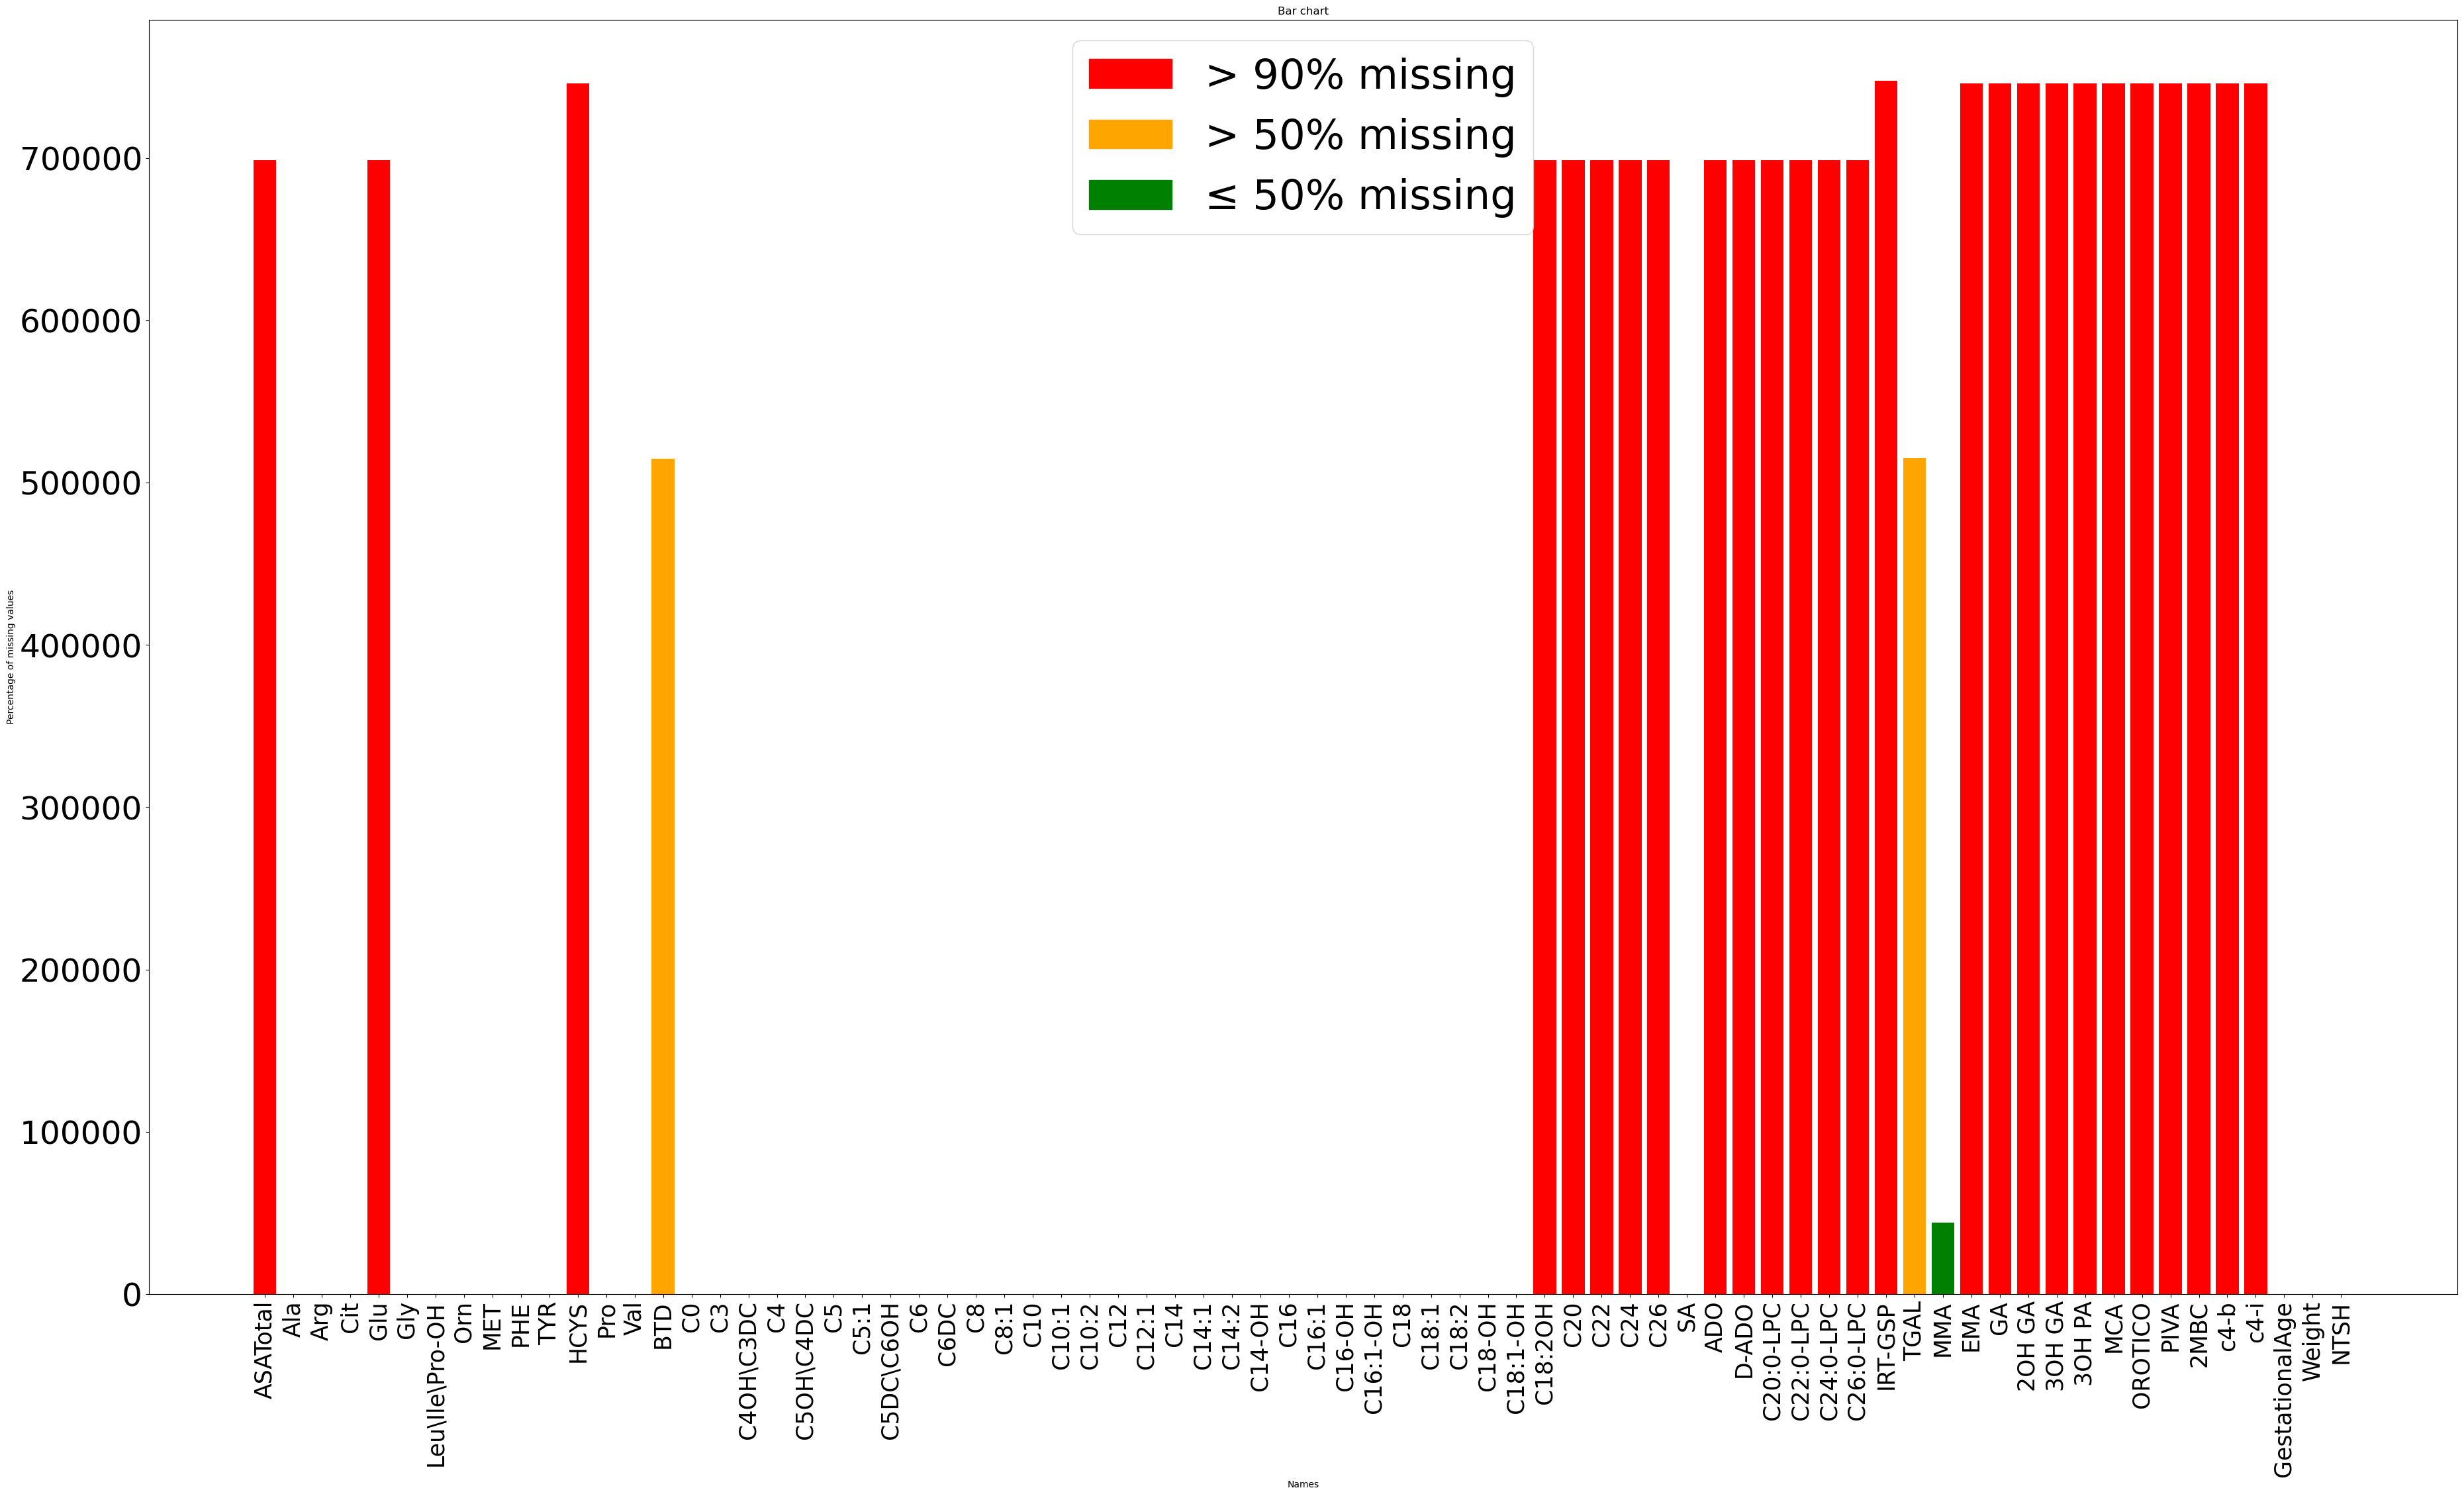

In [111]:
import matplotlib.patches as mpatches

i = 0
x = colonne_numeriche
colors = []
y = []

for val in colonne_numeriche:
    percentage = (babies_def2[val].null_count()/babies_def2.shape[0])*100
    if percentage > 90:
        colors.append('red')
        i = i+1
    elif percentage > 50:
        colors.append('orange')
    else:
        colors.append('green')
    y.append(babies_def2[val].null_count())

plt.figure(figsize=(45, 25))
plt.bar(x, y, color = colors, width= 0.8)
plt.xlabel('Names')
plt.ylabel('Percentage of missing values')
plt.title('Bar chart')
plt.xticks(rotation=90, fontsize = 25)
plt.yticks(fontsize= 35)

red_patch = mpatches.Patch(color='red', label='> 90% missing')
orange_patch = mpatches.Patch(color='orange', label='> 50% missing')
green_patch = mpatches.Patch(color='green', label='≤ 50% missing')

plt.legend(handles=[red_patch, orange_patch, green_patch], fontsize=45, loc = 'upper center', frameon=True)

plt.savefig('missing_new2.png')
plt.show()

In [112]:
set(colors)

{'green', 'orange', 'red'}

In [113]:
perc = []

for val in babies_def2.columns:
    percentage = (babies_def2[val].null_count()/babies_def2.shape[0])*100
    perc.append([percentage, val])

In [114]:
perc

[[93.33218470020675, 'ASATotal'],
 [0.01642812494991425, 'Ala'],
 [0.01642812494991425, 'Arg'],
 [0.01642812494991425, 'Cit'],
 [93.33218470020675, 'Glu'],
 [0.01642812494991425, 'Gly'],
 [0.01642812494991425, 'Leu\\Ile\\Pro-OH'],
 [0.01642812494991425, 'Orn'],
 [0.01642812494991425, 'MET'],
 [0.016027438975526102, 'PHE'],
 [0.016161000966988817, 'TYR'],
 [99.62549217593853, 'HCYS'],
 [0.01642812494991425, 'Pro'],
 [0.01642812494991425, 'Val'],
 [68.74262069997168, 'BTD'],
 [0.01642812494991425, 'C0'],
 [0.01642812494991425, 'C3'],
 [0.016561686941376972, 'C4OH\\C3DC'],
 [0.01642812494991425, 'C4'],
 [0.016561686941376972, 'C5OH\\C4DC'],
 [0.01642812494991425, 'C5'],
 [0.01642812494991425, 'C5:1'],
 [0.016561686941376972, 'C5DC\\C6OH'],
 [0.01642812494991425, 'C6'],
 [0.01642812494991425, 'C6DC'],
 [0.01642812494991425, 'C8'],
 [0.01642812494991425, 'C8:1'],
 [0.01642812494991425, 'C10'],
 [0.01642812494991425, 'C10:1'],
 [0.01642812494991425, 'C10:2'],
 [0.01642812494991425, 'C12'],
 

#### Statistics

In [116]:
statistics_tot = babies_def2[colonne_numeriche].describe()
iq99 = babies_def2.select(pl.col(colonne_numeriche).quantile(0.99))
iq01 = babies_def2.select(pl.col(colonne_numeriche).quantile(0.01))
kurt = babies_def2.select(pl.col(colonne_numeriche).kurtosis())
ske = babies_def2.select(pl.col(colonne_numeriche).skew())
more_stat = pl.concat([iq99, iq01, kurt, ske])
new_col = pl.Series("new_col",['99%','1%','Kurtosis','Skewness'])
more_stat = more_stat.with_columns([new_col])
more_stat = more_stat.rename({"new_col": "statistic"})
more_stat = more_stat.select(["statistic"] + [col for col in more_stat.columns if col != "statistic"])

statistics_tot = pl.concat([statistics_tot, more_stat])
statistics_tot = statistics_tot.with_columns([pl.col(col).round(3).alias(col) if col != "statistic" else pl.col(col) for col in more_stat.columns])

In [117]:
header = statistics_tot["statistic"].to_list()

index = statistics_tot.transpose(include_header=True)

index.columns = ['Name'] + header
index[1:]

Name,count,null_count,mean,std,min,25%,50%,75%,max,99%,1%,Kurtosis,Skewness
str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""ASATotal""","""49923.0""","""698793.0""","""0.287""","""0.176""","""0.036""","""0.187""","""0.248""","""0.333""","""2.957""","""1.032""","""0.095""","""27.357""","""3.926"""
"""Ala""","""748593.0""","""123.0""","""344.391""","""10779.248""","""0.0""","""204.84""","""247.94""","""302.39""","""8401024.23""","""532.802""","""123.89""","""492975.745""","""638.097"""
"""Arg""","""748593.0""","""123.0""","""10.884""","""570.9""","""0.0""","""4.78""","""8.12""","""13.0""","""493407.175""","""36.85""","""1.0""","""745242.791""","""862.322"""
"""Cit""","""748593.0""","""123.0""","""14.302""","""29.472""","""0.0""","""10.44""","""13.23""","""16.58""","""9043.766""","""30.61""","""4.35""","""22212.96""","""120.765"""
"""Glu""","""49923.0""","""698793.0""","""249.371""","""1129.748""","""23.454""","""198.179""","""235.098""","""280.526""","""252238.877""","""443.754""","""129.825""","""49578.527""","""222.288"""
"""Gly""","""748593.0""","""123.0""","""554.746""","""7990.214""","""0.0""","""338.86""","""414.06""","""504.84""","""943330.74""","""901.62""","""165.8""","""5910.235""","""73.346"""
"""Leu\Ile\Pro-OH""","""748593.0""","""123.0""","""187.116""","""2926.021""","""0.0""","""118.63""","""139.78""","""165.32""","""409473.065""","""266.04""","""78.48""","""6989.443""","""79.064"""
"""Orn""","""748593.0""","""123.0""","""127.54""","""2018.12""","""0.0""","""76.75""","""97.33""","""125.39""","""504365.6""","""271.1""","""42.52""","""21635.417""","""132.982"""
"""MET""","""748593.0""","""123.0""","""20.285""","""153.851""","""0.0""","""15.35""","""18.8""","""22.71""","""127393.69""","""38.04""","""8.719""","""627662.716""","""760.44"""


In [118]:
sel = index['Name','null_count','mean','std', 'min', '25%', '50%', '75%', 'max', '99%', '1%', 'Kurtosis']

In [119]:
statistics_tot_pandas = sel.to_pandas()

# Esporta come tabella LaTeX
statistiche_totali = statistics_tot_pandas.to_latex(index=False)

# Salva la tabella LaTeX in un file .tex
with open("statistiche totali.tex", "w") as f:
    f.write(statistiche_totali)

In [120]:
colonne_numeriche

['ASATotal',
 'Ala',
 'Arg',
 'Cit',
 'Glu',
 'Gly',
 'Leu\\Ile\\Pro-OH',
 'Orn',
 'MET',
 'PHE',
 'TYR',
 'HCYS',
 'Pro',
 'Val',
 'BTD',
 'C0',
 'C3',
 'C4OH\\C3DC',
 'C4',
 'C5OH\\C4DC',
 'C5',
 'C5:1',
 'C5DC\\C6OH',
 'C6',
 'C6DC',
 'C8',
 'C8:1',
 'C10',
 'C10:1',
 'C10:2',
 'C12',
 'C12:1',
 'C14',
 'C14:1',
 'C14:2',
 'C14-OH',
 'C16',
 'C16:1',
 'C16-OH',
 'C16:1-OH',
 'C18',
 'C18:1',
 'C18:2',
 'C18-OH',
 'C18:1-OH',
 'C18:2OH',
 'C20',
 'C22',
 'C24',
 'C26',
 'SA',
 'ADO',
 'D-ADO',
 'C20:0-LPC',
 'C22:0-LPC',
 'C24:0-LPC',
 'C26:0-LPC',
 'IRT-GSP',
 'TGAL',
 'MMA',
 'EMA',
 'GA',
 '2OH GA',
 '3OH GA',
 '3OH PA',
 'MCA',
 'OROTICO',
 'PIVA',
 '2MBC',
 'c4-b',
 'c4-i',
 'GestationalAge',
 'Weight',
 'NTSH']

group_c = ['C0', 'C3', 'C4OH\\C3DC', 'C4', 'C5OH\\C4DC', 'C5', 'C5:1', 'C5DC\\C6OH', 'C6', 'C6DC', 'C8', 'C8:1', 'C10', 'C10:1', 'C10:2', 'C12', 'C12:1', 'C14', 'C14:1', 'C14:2', 'C14-OH', 'C16', 'C16:1', 'C16-OH', 'C16:1-OH', 'C18', 'C18:1', 'C18:2', 'C18-OH', 'C18:1-OH']

In [122]:
babies_def2 = babies_def2.drop('check')

In [123]:
babies_def2.write_csv('Dataset_Paper.csv')

### Wheight

#### Bambini che pesano meno di 1,5 kg

In [126]:
extra_piccoli = babies_def2.filter(pl.col('Weight') < 1500)

In [127]:
extra_piccoli.shape

(5966, 100)

In [128]:
statistics_ppp2 = extra_piccoli[colonne_numeriche].describe()
iq99 = extra_piccoli.select(pl.col(colonne_numeriche).quantile(0.99))
iq01 = extra_piccoli.select(pl.col(colonne_numeriche).quantile(0.01))
kurt = extra_piccoli.select(pl.col(colonne_numeriche).kurtosis())
ske = extra_piccoli.select(pl.col(colonne_numeriche).skew())
more_stat = pl.concat([iq99, iq01, kurt, ske])
new_col = pl.Series("new_col",['99%','1%','Kurtosis','Skewness'])
more_stat = more_stat.with_columns([new_col])
more_stat = more_stat.rename({"new_col": "statistic"})
more_stat = more_stat.select(["statistic"] + [col for col in more_stat.columns if col != "statistic"])

statistics_ppp2 = pl.concat([statistics_ppp2, more_stat])
statistics_ppp2 = statistics_ppp2.with_columns([pl.col(col).round(3).alias(col) if col != "statistic" else pl.col(col)for col in more_stat.columns])

In [129]:
statistics_ppp2

statistic,ASATotal,Ala,Arg,Cit,Glu,Gly,Leu\Ile\Pro-OH,Orn,MET,PHE,TYR,HCYS,Pro,Val,BTD,C0,C3,C4OH\C3DC,C4,C5OH\C4DC,C5,C5:1,C5DC\C6OH,C6,C6DC,C8,C8:1,C10,C10:1,C10:2,C12,C12:1,C14,C14:1,C14:2,C14-OH,C16,C16:1,C16-OH,C16:1-OH,C18,C18:1,C18:2,C18-OH,C18:1-OH,C18:2OH,C20,C22,C24,C26,SA,ADO,D-ADO,C20:0-LPC,C22:0-LPC,C24:0-LPC,C26:0-LPC,IRT-GSP,TGAL,MMA,EMA,GA,2OH GA,3OH GA,3OH PA,MCA,OROTICO,PIVA,2MBC,c4-b,c4-i,GestationalAge,Weight,NTSH
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",363.0,5966.0,5966.0,5966.0,363.0,5966.0,5966.0,5966.0,5966.0,5966.0,5966.0,37.0,5966.0,5966.0,1779.0,5966.0,5966.0,5966.0,5966.0,5966.0,5966.0,5966.0,5966.0,5966.0,5966.0,5966.0,5966.0,5966.0,5966.0,5966.0,5966.0,5966.0,5966.0,5966.0,5966.0,5966.0,5966.0,5966.0,5966.0,5966.0,5966.0,5966.0,5966.0,5966.0,5966.0,363.0,363.0,363.0,363.0,363.0,5966.0,363.0,363.0,363.0,363.0,363.0,363.0,7.0,1777.0,5656.0,37.0,37.0,37.0,37.0,37.0,37.0,37.0,37.0,37.0,37.0,37.0,5966.0,5966.0,5966.0
"""null_count""",5603.0,0.0,0.0,0.0,5603.0,0.0,0.0,0.0,0.0,0.0,0.0,5929.0,0.0,0.0,4187.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5603.0,5603.0,5603.0,5603.0,5603.0,0.0,5603.0,5603.0,5603.0,5603.0,5603.0,5603.0,5959.0,4189.0,310.0,5929.0,5929.0,5929.0,5929.0,5929.0,5929.0,5929.0,5929.0,5929.0,5929.0,5929.0,0.0,0.0,0.0
"""mean""",0.373,730.557,117.452,19.816,250.195,1240.835,632.043,354.193,68.362,211.537,309.076,2.117,1556.58,930.751,217.695,39.748,3.034,0.144,0.454,0.19,0.384,0.015,0.125,0.057,0.077,0.091,0.094,0.059,0.063,0.01,0.041,0.032,0.152,0.072,0.03,0.008,1.695,0.134,0.012,0.039,0.91,1.506,0.631,0.007,0.021,0.023,0.034,0.012,0.014,0.013,0.831,1.111,0.022,0.369,0.364,0.477,0.33,26.718,1.788,0.006,0.933,1.938,15.256,0.348,17.124,12270.046,0.47,0.019,0.293,0.316,1.196,29.775,1154.136,2.055
"""std""",0.213,12666.073,6388.356,84.738,82.511,22900.921,10637.838,7522.102,1666.985,3995.467,10502.069,1.254,72720.957,18939.656,67.249,112.202,1.628,0.138,0.279,0.077,0.208,0.008,0.11,0.036,0.037,0.06,0.063,0.048,0.048,0.012,0.023,0.021,0.072,0.04,0.018,0.005,0.991,0.069,0.009,0.015,0.526,0.723,0.412,0.009,0.016,0.009,0.016,0.007,0.008,0.008,0.533,0.505,0.02,0.235,0.221,0.232,0.211,7.849,1.571,0.205,0.486,0.914,7.673,0.2,8.591,8051.695,0.277,0.014,0.158,0.471,5.732,2.905,280.631,4.8
"""min""",0.092,0.0,0.0,0.0,96.167,0.0,41.43,6.37,3.37,19.93,0.0,0.463,27.55,30.29,36.681,6.18,0.31,0.0,0.06,0.0,0.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.01,0.0,0.0,0.0,0.08,0.01,0.0,0.0,0.14,0.04,0.01,0.0,0.0,0.004,0.007,0.004,0.004,0.004,0.0,0.234,0.007,0.037,0.042,0.07,0.045,16.436,0.0,0.0,0.216,0.696,3.218,0.012,2.807,0.194,0.06,0.0,0.062,0.031,0.052,23.0,350.0,0.0
"""25%""",0.247,189.26,13.14,11.84,188.029,350.65,185.099,101.49,22.07,66.23,49.35,1.233,138.48,159.12,164.232,21.97,2.002,0.1,0.29,0.14,0.25,0.01,0.09,0.04,0.05,0.059,0.05,0.04,0.03,0.0,0.03,0.02,0.1,0.05,0.02,0.007,1.08,0.09,0.01,0.03,0.65,1.06,0.38,0.0,0.01,0.016,0.024,0.008,0.009,0.008,0.59,0.81,0.014,0.219,0.22,0.327,0.194,25.828,0.688,0.0,0.6,1.268,9.298,0.228,7.838,6599.051,0.285,0.006,0.172,0.073,0.161,28.0,956.0,0.916
"""50%""",0.321,248.6,24.37,15.63,240.361,443.192,228.58,138.59,30.82,78.9,75.31,1.776,178.73,202.84,213.402,31.24,2.75,0.13,0.39,0.18,0.34,0.01,0.11,0.05,0.07,0.08,0.08,0.05,0.05,0.01,0.04,0.03,0.14,0.062,0.03,0.01,1.51,0.12,0.01,0.04,0.85,1.39,0.57,0.01,0.02,0.021,0.03,0.01,0.012,0.011,0.81,1.027,0.018,0.31,0.307,0.432,0.281,26.081,1.311,0.0,0.82,1.637,14.638,0.369,17.86,12917.59,0.375,0.018,0.264,0.135,0.244,30.0,1210.0,1.571
"""75%""",0.448,337.76,40.7,20.11,299.02,554.67,278.16,184.42,42.8,94.38,117.778,2.743,235.57,251.33,270.806,47.56,3.75,0.18,0.54,0.22,0.46,0.02,0.15

In [130]:
header = statistics_ppp2["statistic"].to_list()

prova = statistics_ppp2.transpose(include_header=True)

prova.columns = ['Name'] + header
prova[1:]

prova_bis = prova['Name','null_count','mean','std', 'min', '25%', '50%', '75%', 'max', '99%', '1%', 'Kurtosis']

In [131]:
statistics_ppp2_pandas = prova_bis.to_pandas()

# Esporta come tabella LaTeX
statistiche_1500 = statistics_ppp2_pandas.to_latex(index=False)

# Salva la tabella LaTeX in un file .tex
with open("extra_piccoli.tex", "w") as f:
    f.write(statistiche_1500)

In [132]:
len(colonne_numeriche)

74

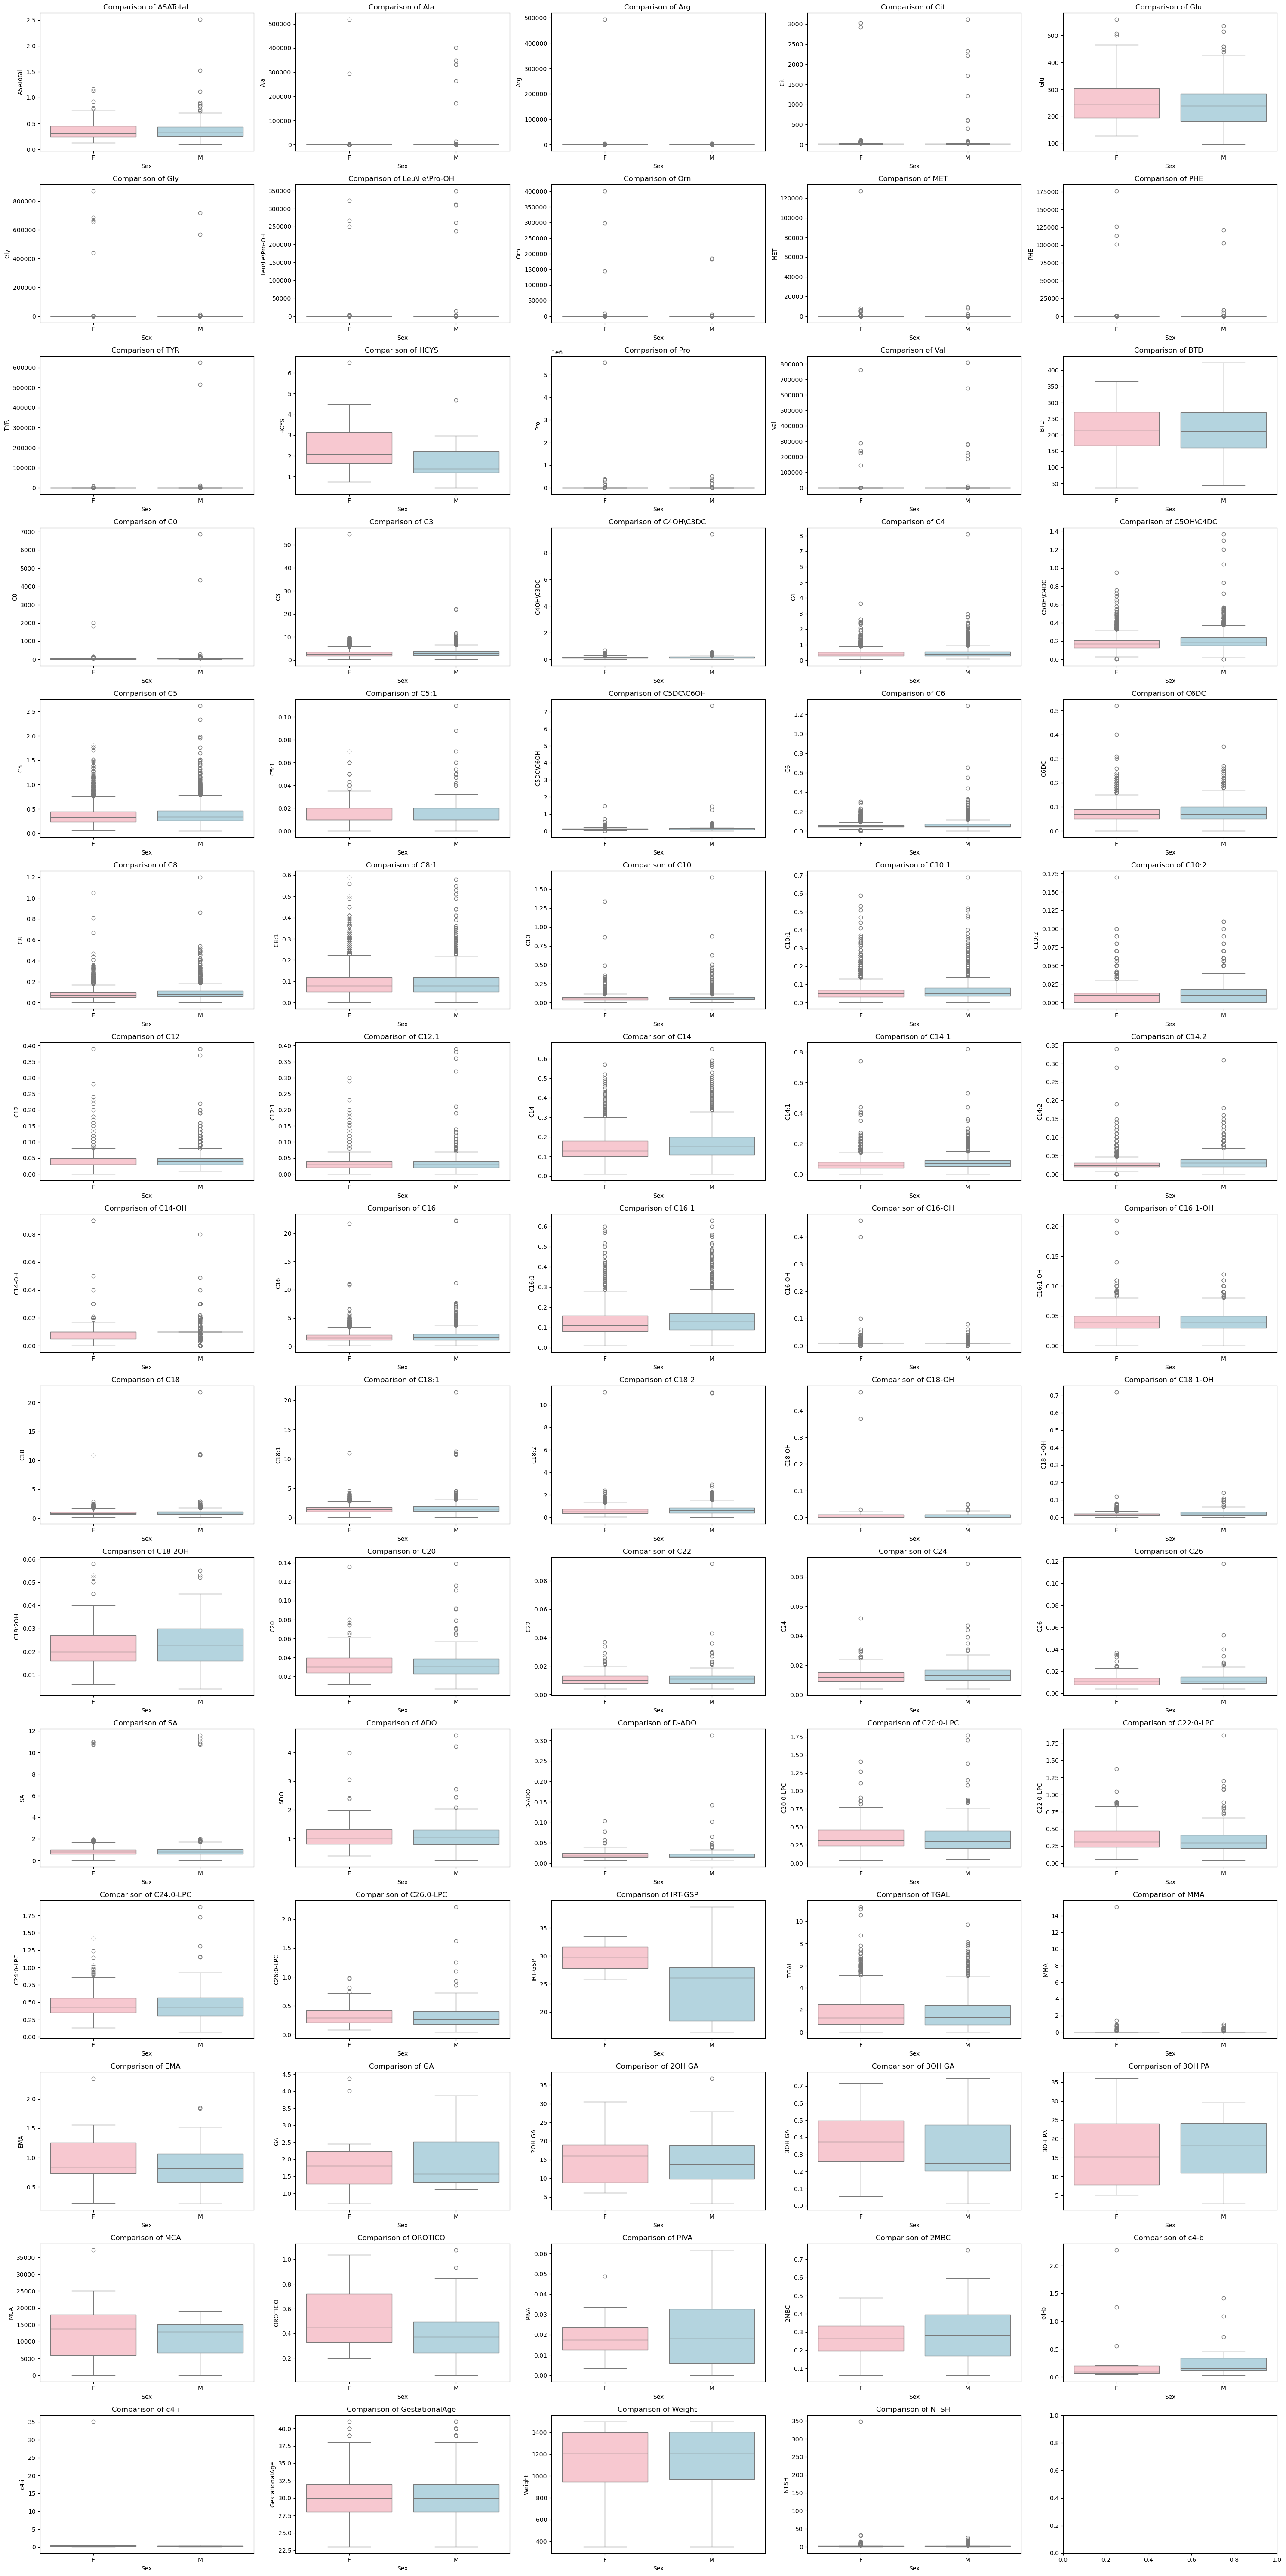

In [133]:
extra_piccoli_pandas = extra_piccoli.to_pandas()

fig, axes = plt.subplots(15, 5, figsize=(30, 60)) 

i, j = 0, 0  # Assicurati di inizializzare `i` e `j` correttamente per indicizzare gli assi
for col in colonne_numeriche: 
    sns.boxplot(
        x='Sex', 
        y=col, 
        ax=axes[i, j], 
        data=extra_piccoli_pandas, 
        hue='Sex', 
        palette={'M': 'lightblue', 'F': 'pink'}
    )  
    axes[i, j].set_title(f'Comparison of {col} ')
    j += 1
    if j == 5:  # Passa alla riga successiva
        i += 1
        j = 0

plt.tight_layout()
plt.savefig('Extrapiccoli.png')
plt.show()


#### Bambini che pesano tra 2 e 1,5 kg

In [294]:
piccoli_pic = babies_def2.filter((pl.col('Weight') >= 1500) & (pl.col('Weight') < 2000))
piccoli_pic.shape

(9172, 100)

In [296]:
statistics_pp2 = piccoli_pic[colonne_numeriche].describe()
iq99 = piccoli_pic.select(pl.col(colonne_numeriche).quantile(0.99))
iq01 = piccoli_pic.select(pl.col(colonne_numeriche).quantile(0.01))
kurt = piccoli_pic.select(pl.col(colonne_numeriche).kurtosis())
ske = piccoli_pic.select(pl.col(colonne_numeriche).skew())
more_stat = pl.concat([iq99, iq01, kurt, ske])
new_col = pl.Series("new_col",['99%','1%','Kurtosis','Skewness'])
more_stat = more_stat.with_columns([new_col])
more_stat = more_stat.rename({"new_col": "statistic"})
more_stat = more_stat.select(["statistic"] + [col for col in more_stat.columns if col != "statistic"])

statistics_pp2 = pl.concat([statistics_pp2, more_stat])
statistics_pp2 = statistics_pp2.with_columns([pl.col(col).round(3).alias(col) if col != "statistic" else pl.col(col)for col in more_stat.columns])

In [300]:
statistics_pp2

statistic,ASATotal,Ala,Arg,Cit,Glu,Gly,Leu\Ile\Pro-OH,Orn,MET,PHE,TYR,HCYS,Pro,Val,BTD,C0,C3,C4OH\C3DC,C4,C5OH\C4DC,C5,C5:1,C5DC\C6OH,C6,C6DC,C8,C8:1,C10,C10:1,C10:2,C12,C12:1,C14,C14:1,C14:2,C14-OH,C16,C16:1,C16-OH,C16:1-OH,C18,C18:1,C18:2,C18-OH,C18:1-OH,C18:2OH,C20,C22,C24,C26,SA,ADO,D-ADO,C20:0-LPC,C22:0-LPC,C24:0-LPC,C26:0-LPC,IRT-GSP,TGAL,MMA,EMA,GA,2OH GA,3OH GA,3OH PA,MCA,OROTICO,PIVA,2MBC,c4-b,c4-i,GestationalAge,Weight,NTSH
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",537.0,9168.0,9168.0,9168.0,537.0,9168.0,9168.0,9168.0,9168.0,9168.0,9168.0,46.0,9168.0,9168.0,2693.0,9168.0,9168.0,9168.0,9168.0,9168.0,9168.0,9168.0,9168.0,9168.0,9168.0,9168.0,9168.0,9168.0,9168.0,9168.0,9168.0,9168.0,9168.0,9168.0,9168.0,9168.0,9168.0,9168.0,9168.0,9168.0,9168.0,9168.0,9168.0,9168.0,9168.0,537.0,537.0,537.0,537.0,537.0,9168.0,537.0,537.0,537.0,537.0,537.0,537.0,12.0,2692.0,8705.0,46.0,46.0,46.0,46.0,46.0,46.0,46.0,46.0,46.0,46.0,46.0,9172.0,9172.0,9172.0
"""null_count""",8635.0,4.0,4.0,4.0,8635.0,4.0,4.0,4.0,4.0,4.0,4.0,9126.0,4.0,4.0,6479.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,8635.0,8635.0,8635.0,8635.0,8635.0,4.0,8635.0,8635.0,8635.0,8635.0,8635.0,8635.0,9160.0,6480.0,467.0,9126.0,9126.0,9126.0,9126.0,9126.0,9126.0,9126.0,9126.0,9126.0,9126.0,9126.0,0.0,0.0,0.0
"""mean""",0.279,353.673,17.533,14.368,242.547,854.31,218.1,166.65,27.403,97.235,1486.149,2.16,305.776,156.508,212.682,29.935,2.587,0.114,0.302,0.175,0.211,0.01,0.113,0.047,0.082,0.058,0.065,0.058,0.049,0.005,0.062,0.041,0.198,0.081,0.021,0.009,2.546,0.182,0.014,0.042,0.964,1.726,0.379,0.009,0.022,0.017,0.035,0.011,0.014,0.013,0.804,0.832,0.02,0.363,0.293,0.484,0.31,20.015,2.197,0.003,1.095,2.065,18.476,0.289,15.802,10752.253,0.402,0.009,0.184,0.28,0.203,33.912,1805.237,2.322
"""std""",0.207,5363.066,81.008,31.046,75.106,14959.482,3843.236,4068.511,99.329,2015.987,132230.53,1.218,7904.06,2010.787,61.366,70.369,1.814,0.054,0.207,0.075,0.118,0.007,0.117,0.022,0.039,0.049,0.037,0.041,0.027,0.007,0.036,0.028,0.081,0.043,0.01,0.006,1.178,0.086,0.007,0.016,0.433,0.713,0.264,0.005,0.01,0.006,0.023,0.007,0.008,0.009,0.383,0.326,0.02,0.248,0.216,0.265,0.209,8.662,2.033,0.044,1.352,1.364,11.234,0.21,9.13,6605.581,0.219,0.009,0.124,0.321,0.121,1.99,132.193,3.501
"""min""",0.08,0.0,0.0,0.0,95.927,0.0,0.0,0.0,0.0,0.0,0.0,0.701,0.0,0.0,4.168,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.002,0.007,0.003,0.004,0.003,0.0,0.25,0.006,0.057,0.054,0.167,0.064,9.177,0.0,0.0,0.362,0.276,4.667,0.014,1.27,0.0,0.08,0.0,0.0,0.039,0.04,23.0,1500.0,0.0
"""25%""",0.176,179.4,5.21,9.92,191.065,318.4,114.51,68.03,16.89,49.5,61.37,1.359,121.07,86.17,165.722,18.5,1.66,0.08,0.19,0.13,0.13,0.01,0.08,0.03,0.06,0.04,0.04,0.036,0.03,0.0,0.04,0.02,0.14,0.05,0.01,0.01,1.76,0.12,0.01,0.03,0.71,1.28,0.228,0.01,0.02,0.013,0.022,0.008,0.009,0.008,0.57,0.608,0.013,0.224,0.175,0.336,0.192,13.733,0.915,0.0,0.685,1.131,11.094,0.122,6.716,6248.572,0.25,0.001,0.1,0.087,0.105,32.0,1700.0,1.117
"""50%""",0.233,231.74,9.78,12.84,232.338,401.64,148.176,96.23,22.47,59.96,86.55,1.74,151.84,115.55,208.395,24.82,2.28,0.1,0.26,0.17,0.18,0.01,0.1,0.04,0.08,0.05,0.06,0.05,0.04,0.0,0.05,0.03,0.188,0.07,0.02,0.01,2.38,0.17,0.01,0.04,0.9,1.64,0.33,0.01,0.02,0.016,0.03,0.009,0.012,0.011,0.78,0.785,0.017,0.299,0.239,0.416,0.255,18.386,1.723,0.0,0.872,1.619,16.275,0.249,15.941,9864.037,0.326,0.008,0.158,0.133,0.183,34.0,1825.0,1.803
"""75%""",0.306,300.06,18.68,16.69,283.528,502.4,196.47,137.11,29.78,73.75,125.55,2.776,190.4,162.32,259.334,34.21,3.14,0.14,0.35,0.21,0.25,0.01,0.13,0.06,0.1,0.07,0.08,0.07,0.06,0.01,0.08,0.05

In [137]:
header = statistics_pp2["statistic"].to_list()

prova2 = statistics_pp2.transpose(include_header=True)

prova2.columns = ['Name'] + header
prova2[1:]
unoemezzodue = prova2['Name','null_count','mean','std', 'min', '25%', '50%', '75%', 'max', '99%', '1%', 'Kurtosis']

In [138]:
statistics_pp2_pandas = unoemezzodue.to_pandas()

# Esporta come tabella LaTeX
statistiche_2000 = statistics_pp2_pandas.to_latex(index=False)

# Salva la tabella LaTeX in un file .tex
with open("unoemezzodue_table.tex", "w") as f:
    f.write(statistiche_2000)

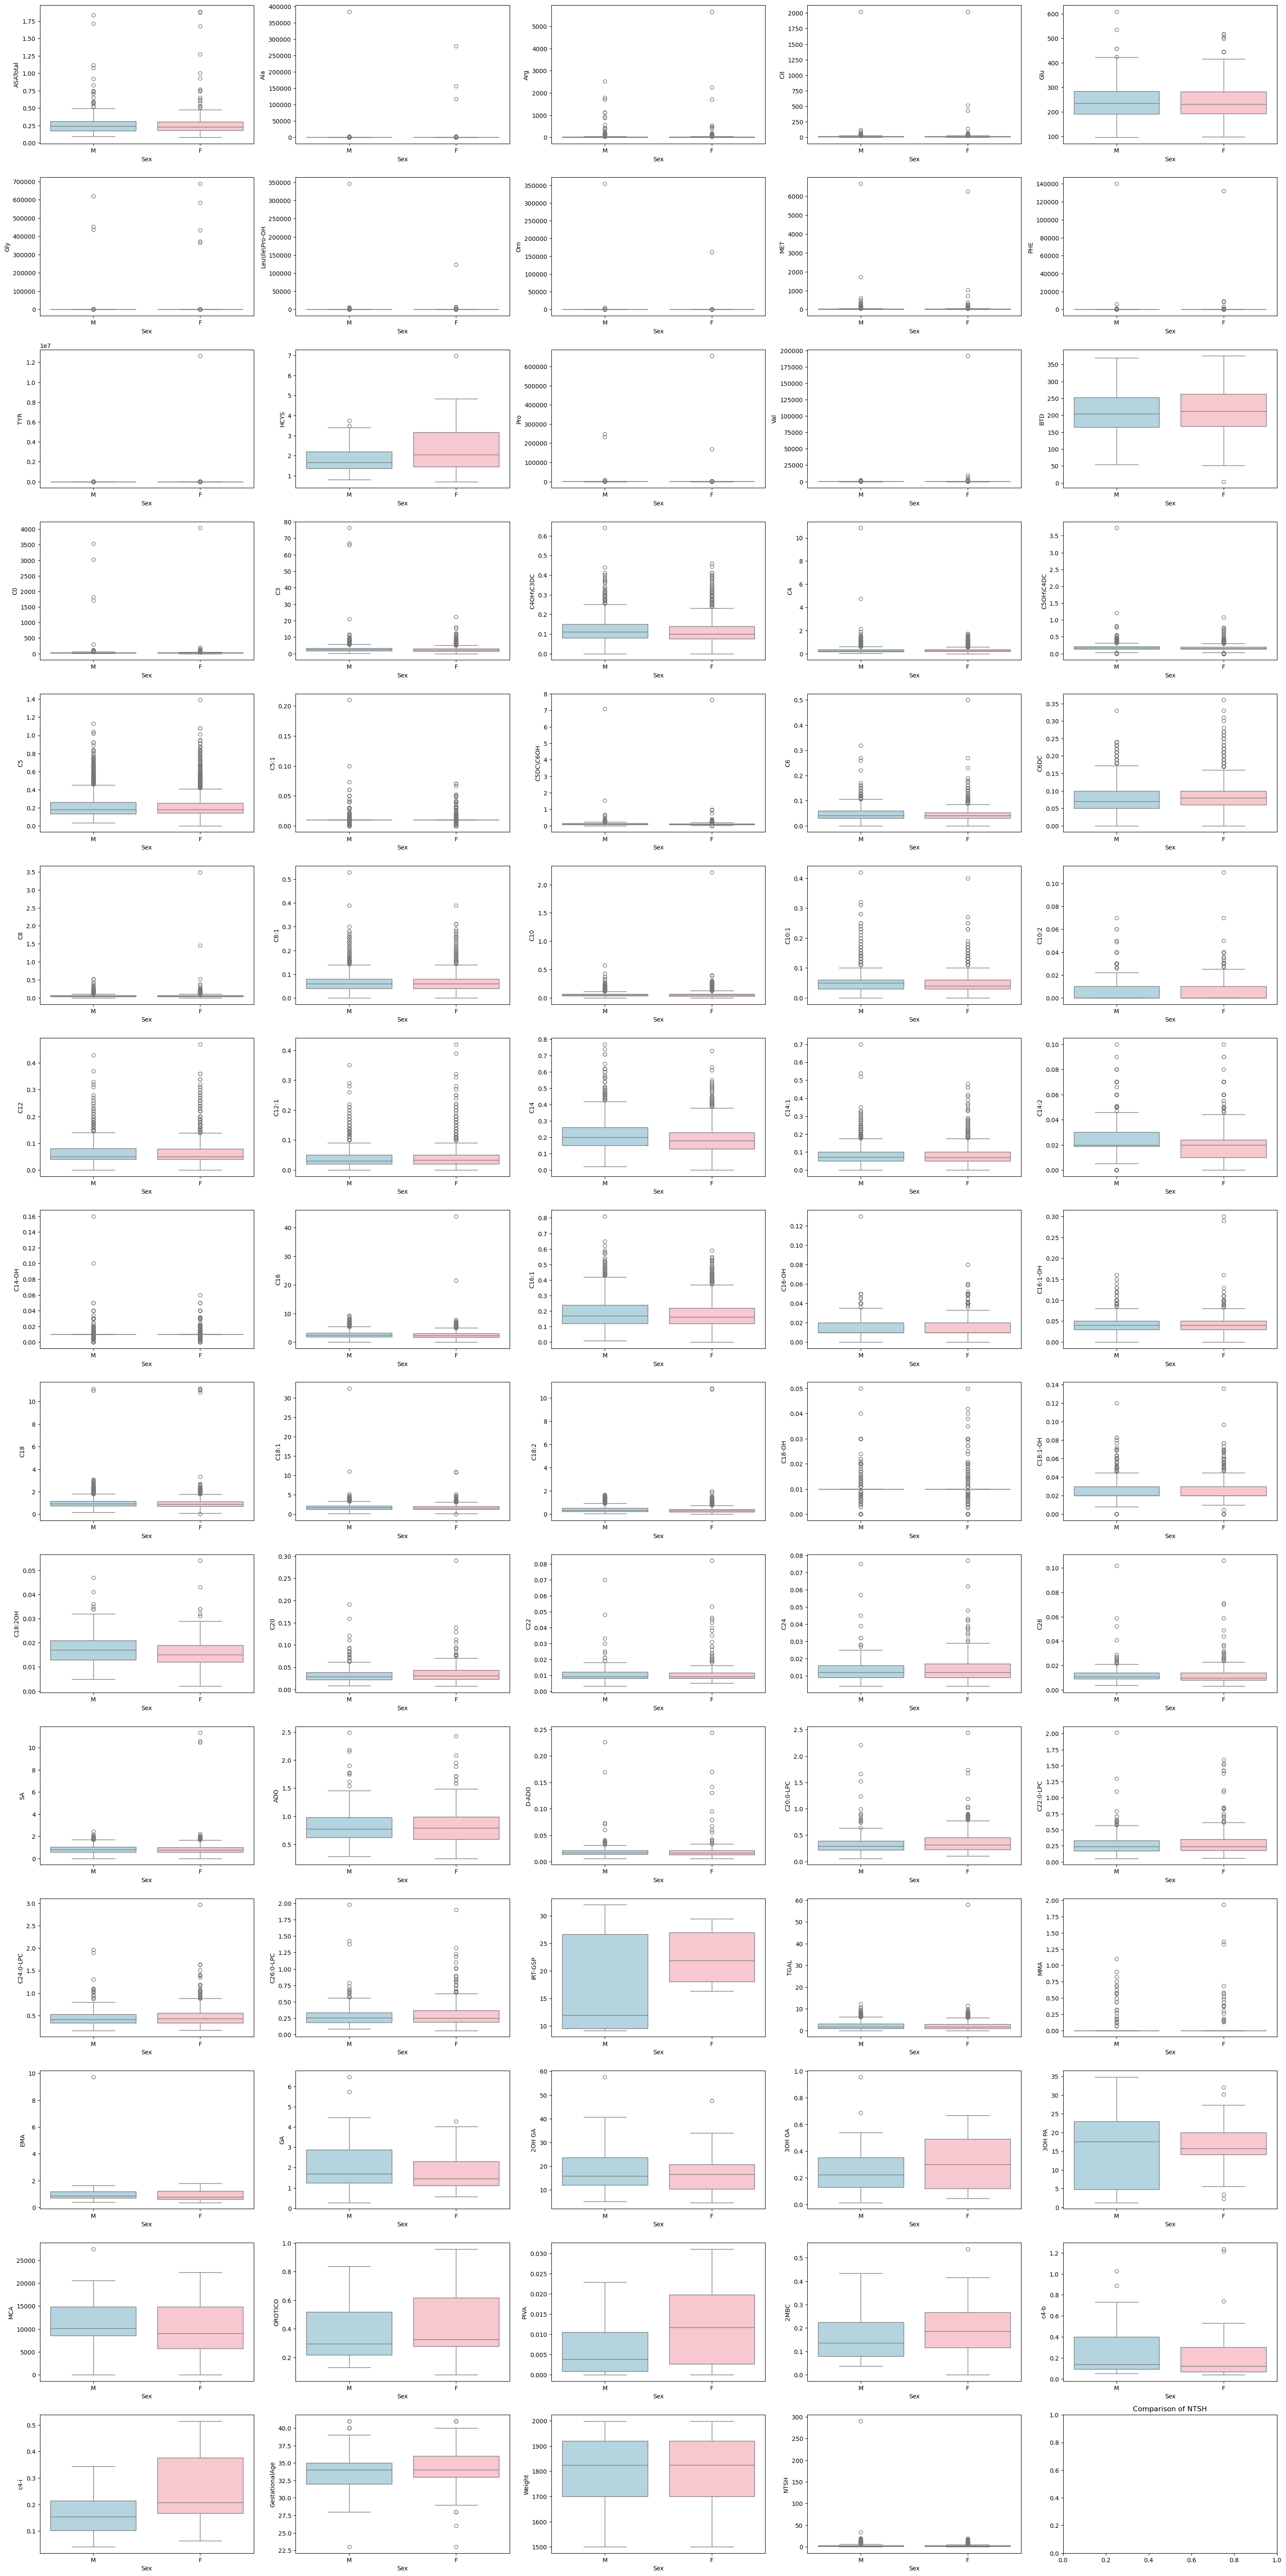

In [139]:
j = 0
i = 0
piccoli_picp = piccoli_pic.to_pandas()

fig, axes = plt.subplots(15, 5, figsize=(30, 60)) 
for col in colonne_numeriche: 
    
    sns.boxplot(x='Sex', y= col, ax = axes[i,j], data=piccoli_picp, hue='Sex', palette={'M': 'lightblue', 'F': 'pink'})  
    plt.title(f'Comparison of {col}')
    #plt.show()
    #plt.xticks(fontsize=20)  
    #plt.yticks(fontsize=40)
    j = j+1
    if j % 5 == 0:
        i = i + 1
        j = 0    

plt.savefig('F_M_piccoli.png')
plt.tight_layout()

####  Bambini che pesano tra 2 kg di 2,5 kg

In [141]:
piccoli = babies_def2.filter((pl.col('Weight') < 2500) & (pl.col('Weight') >= 2000))
piccoli.shape


(35527, 100)

In [142]:
statistics_p2 = piccoli[colonne_numeriche].describe()
iq99 = piccoli.select(pl.col(colonne_numeriche).quantile(0.99))
iq01 = piccoli.select(pl.col(colonne_numeriche).quantile(0.01))
kurt = piccoli.select(pl.col(colonne_numeriche).kurtosis())
ske = piccoli.select(pl.col(colonne_numeriche).skew())
more_stat = pl.concat([iq99, iq01, kurt, ske])
new_col = pl.Series("new_col",['99%','1%','Kurtosis','Skewness'])
more_stat = more_stat.with_columns([new_col])
more_stat = more_stat.rename({"new_col": "statistic"})
more_stat = more_stat.select(["statistic"] + [col for col in more_stat.columns if col != "statistic"])

statistics_p2 = pl.concat([statistics_p2, more_stat])
statistics_p2 = statistics_p2.with_columns([pl.col(col).round(3).alias(col) if col != "statistic" else pl.col(col)for col in more_stat.columns])
statistics_p2

statistic,ASATotal,Ala,Arg,Cit,Glu,Gly,Leu\Ile\Pro-OH,Orn,MET,PHE,TYR,HCYS,Pro,Val,BTD,C0,C3,C4OH\C3DC,C4,C5OH\C4DC,C5,C5:1,C5DC\C6OH,C6,C6DC,C8,C8:1,C10,C10:1,C10:2,C12,C12:1,C14,C14:1,C14:2,C14-OH,C16,C16:1,C16-OH,C16:1-OH,C18,C18:1,C18:2,C18-OH,C18:1-OH,C18:2OH,C20,C22,C24,C26,SA,ADO,D-ADO,C20:0-LPC,C22:0-LPC,C24:0-LPC,C26:0-LPC,IRT-GSP,TGAL,MMA,EMA,GA,2OH GA,3OH GA,3OH PA,MCA,OROTICO,PIVA,2MBC,c4-b,c4-i,GestationalAge,Weight,NTSH
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",2296.0,35521.0,35521.0,35521.0,2296.0,35521.0,35521.0,35521.0,35521.0,35522.0,35521.0,158.0,35521.0,35521.0,10850.0,35521.0,35521.0,35521.0,35521.0,35521.0,35521.0,35521.0,35521.0,35521.0,35521.0,35521.0,35521.0,35521.0,35521.0,35521.0,35521.0,35521.0,35521.0,35521.0,35521.0,35521.0,35521.0,35521.0,35522.0,35521.0,35521.0,35521.0,35521.0,35521.0,35521.0,2296.0,2296.0,2296.0,2296.0,2296.0,35521.0,2296.0,2296.0,2296.0,2296.0,2296.0,2296.0,42.0,10839.0,33510.0,158.0,158.0,158.0,158.0,158.0,158.0,158.0,158.0,158.0,158.0,158.0,35527.0,35527.0,35527.0
"""null_count""",33231.0,6.0,6.0,6.0,33231.0,6.0,6.0,6.0,6.0,5.0,6.0,35369.0,6.0,6.0,24677.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,5.0,6.0,6.0,6.0,6.0,6.0,6.0,33231.0,33231.0,33231.0,33231.0,33231.0,6.0,33231.0,33231.0,33231.0,33231.0,33231.0,33231.0,35485.0,24688.0,2017.0,35369.0,35369.0,35369.0,35369.0,35369.0,35369.0,35369.0,35369.0,35369.0,35369.0,35369.0,0.0,0.0,0.0
"""mean""",0.269,325.408,10.914,13.416,243.411,535.763,195.043,126.019,22.292,64.76,141.91,3.099,240.38,124.651,220.602,23.756,2.202,0.152,0.265,0.186,0.144,0.009,0.122,0.047,0.108,0.063,0.056,0.084,0.055,0.004,0.102,0.07,0.228,0.114,0.023,0.014,3.235,0.226,0.02,0.044,1.052,1.803,0.27,0.013,0.025,0.014,0.052,0.012,0.019,0.013,0.809,0.679,0.02,0.337,0.25,0.5,0.297,18.996,2.32,0.003,0.913,1.578,16.135,0.291,14.557,10223.687,0.397,0.015,0.115,0.162,0.151,36.426,2302.67,2.706
"""std""",0.179,4502.878,53.557,27.059,72.803,7837.197,3185.249,2134.796,65.144,1154.421,3183.922,2.724,4139.314,1091.825,57.781,63.869,1.252,0.077,0.151,0.068,0.07,0.007,0.046,0.021,0.051,0.034,0.031,0.048,0.022,0.006,0.064,0.049,0.093,0.067,0.011,0.009,1.313,0.093,0.015,0.017,0.443,0.669,0.141,0.01,0.014,0.005,0.037,0.007,0.011,0.009,0.414,0.266,0.019,0.224,0.168,0.258,0.186,7.535,1.788,0.183,0.702,0.735,7.305,0.198,8.865,8304.851,0.72,0.08,0.068,0.201,0.093,1.767,137.88,4.435
"""min""",0.05,0.0,0.0,0.0,87.504,0.0,0.0,0.0,0.0,16.15,6.48,0.641,0.0,0.0,20.313,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.004,0.008,0.004,0.004,0.003,0.0,0.176,0.003,0.063,0.051,0.132,0.06,8.876,0.0,0.0,0.157,0.229,5.845,0.03,0.305,0.0,0.0,0.0,0.0,0.021,0.007,25.0,2000.0,0.0
"""25%""",0.176,194.69,4.49,9.698,191.468,337.32,111.23,71.25,16.04,46.75,71.27,1.861,137.99,89.27,177.377,15.55,1.48,0.1,0.18,0.14,0.1,0.01,0.09,0.03,0.075,0.04,0.03,0.05,0.04,0.0,0.06,0.04,0.17,0.07,0.02,0.01,2.37,0.16,0.01,0.03,0.78,1.38,0.17,0.01,0.02,0.01,0.03,0.008,0.013,0.008,0.57,0.495,0.013,0.196,0.155,0.346,0.199,13.443,1.059,0.0,0.641,1.054,10.567,0.131,5.07,5435.958,0.234,0.001,0.066,0.063,0.095,35.0,2200.0,1.412
"""50%""",0.232,242.68,7.8,12.34,232.42,417.65,132.74,92.93,19.92,54.46,95.02,2.685,166.84,109.48,220.542,20.44,1.97,0.14,0.23,0.18,0.13,0.01,0.12,0.04,0.1,0.06,0.05,0.07,0.05,0.0,0.09,0.06,0.21,0.1,0.02,0.01,3.06,0.21,0.02,0.04,0.99,1.72,0.24,0.01,0.02,0.013,0.043,0.01,0.016,0.011,0.79,0.643,0.016,0.27,0.204,0.44,0.252,17.8,1.887,0.0,0.814,1.4,14.46,0.269,15.593,9482.503,0.314,0.003,0.097,0.096,0.134,37.0,2330.0,2.207
"""75%""",0.305,302.13,12.86,15.61,282.835,511.66,159.15,121.57,24.55,63.56,129.025,3.461,200.71,13

In [143]:
header = statistics_p2["statistic"].to_list()

prova3 = statistics_p2.transpose(include_header=True)

prova3.columns = ['Name'] + header
prova3[1:]

duemezzo = prova3['Name','null_count','mean','std', 'min', '25%', '50%', '75%', 'max', '99%', '1%', 'Kurtosis']

In [144]:
statistics_p2_pandas = duemezzo.to_pandas()
# Esporta come tabella LaTeX
statistiche_2500 = statistics_p2_pandas.to_latex(index=False)

# Salva la tabella LaTeX in un file .tex
with open("duemezzo_table.tex", "w") as f:
    f.write(statistiche_2500)

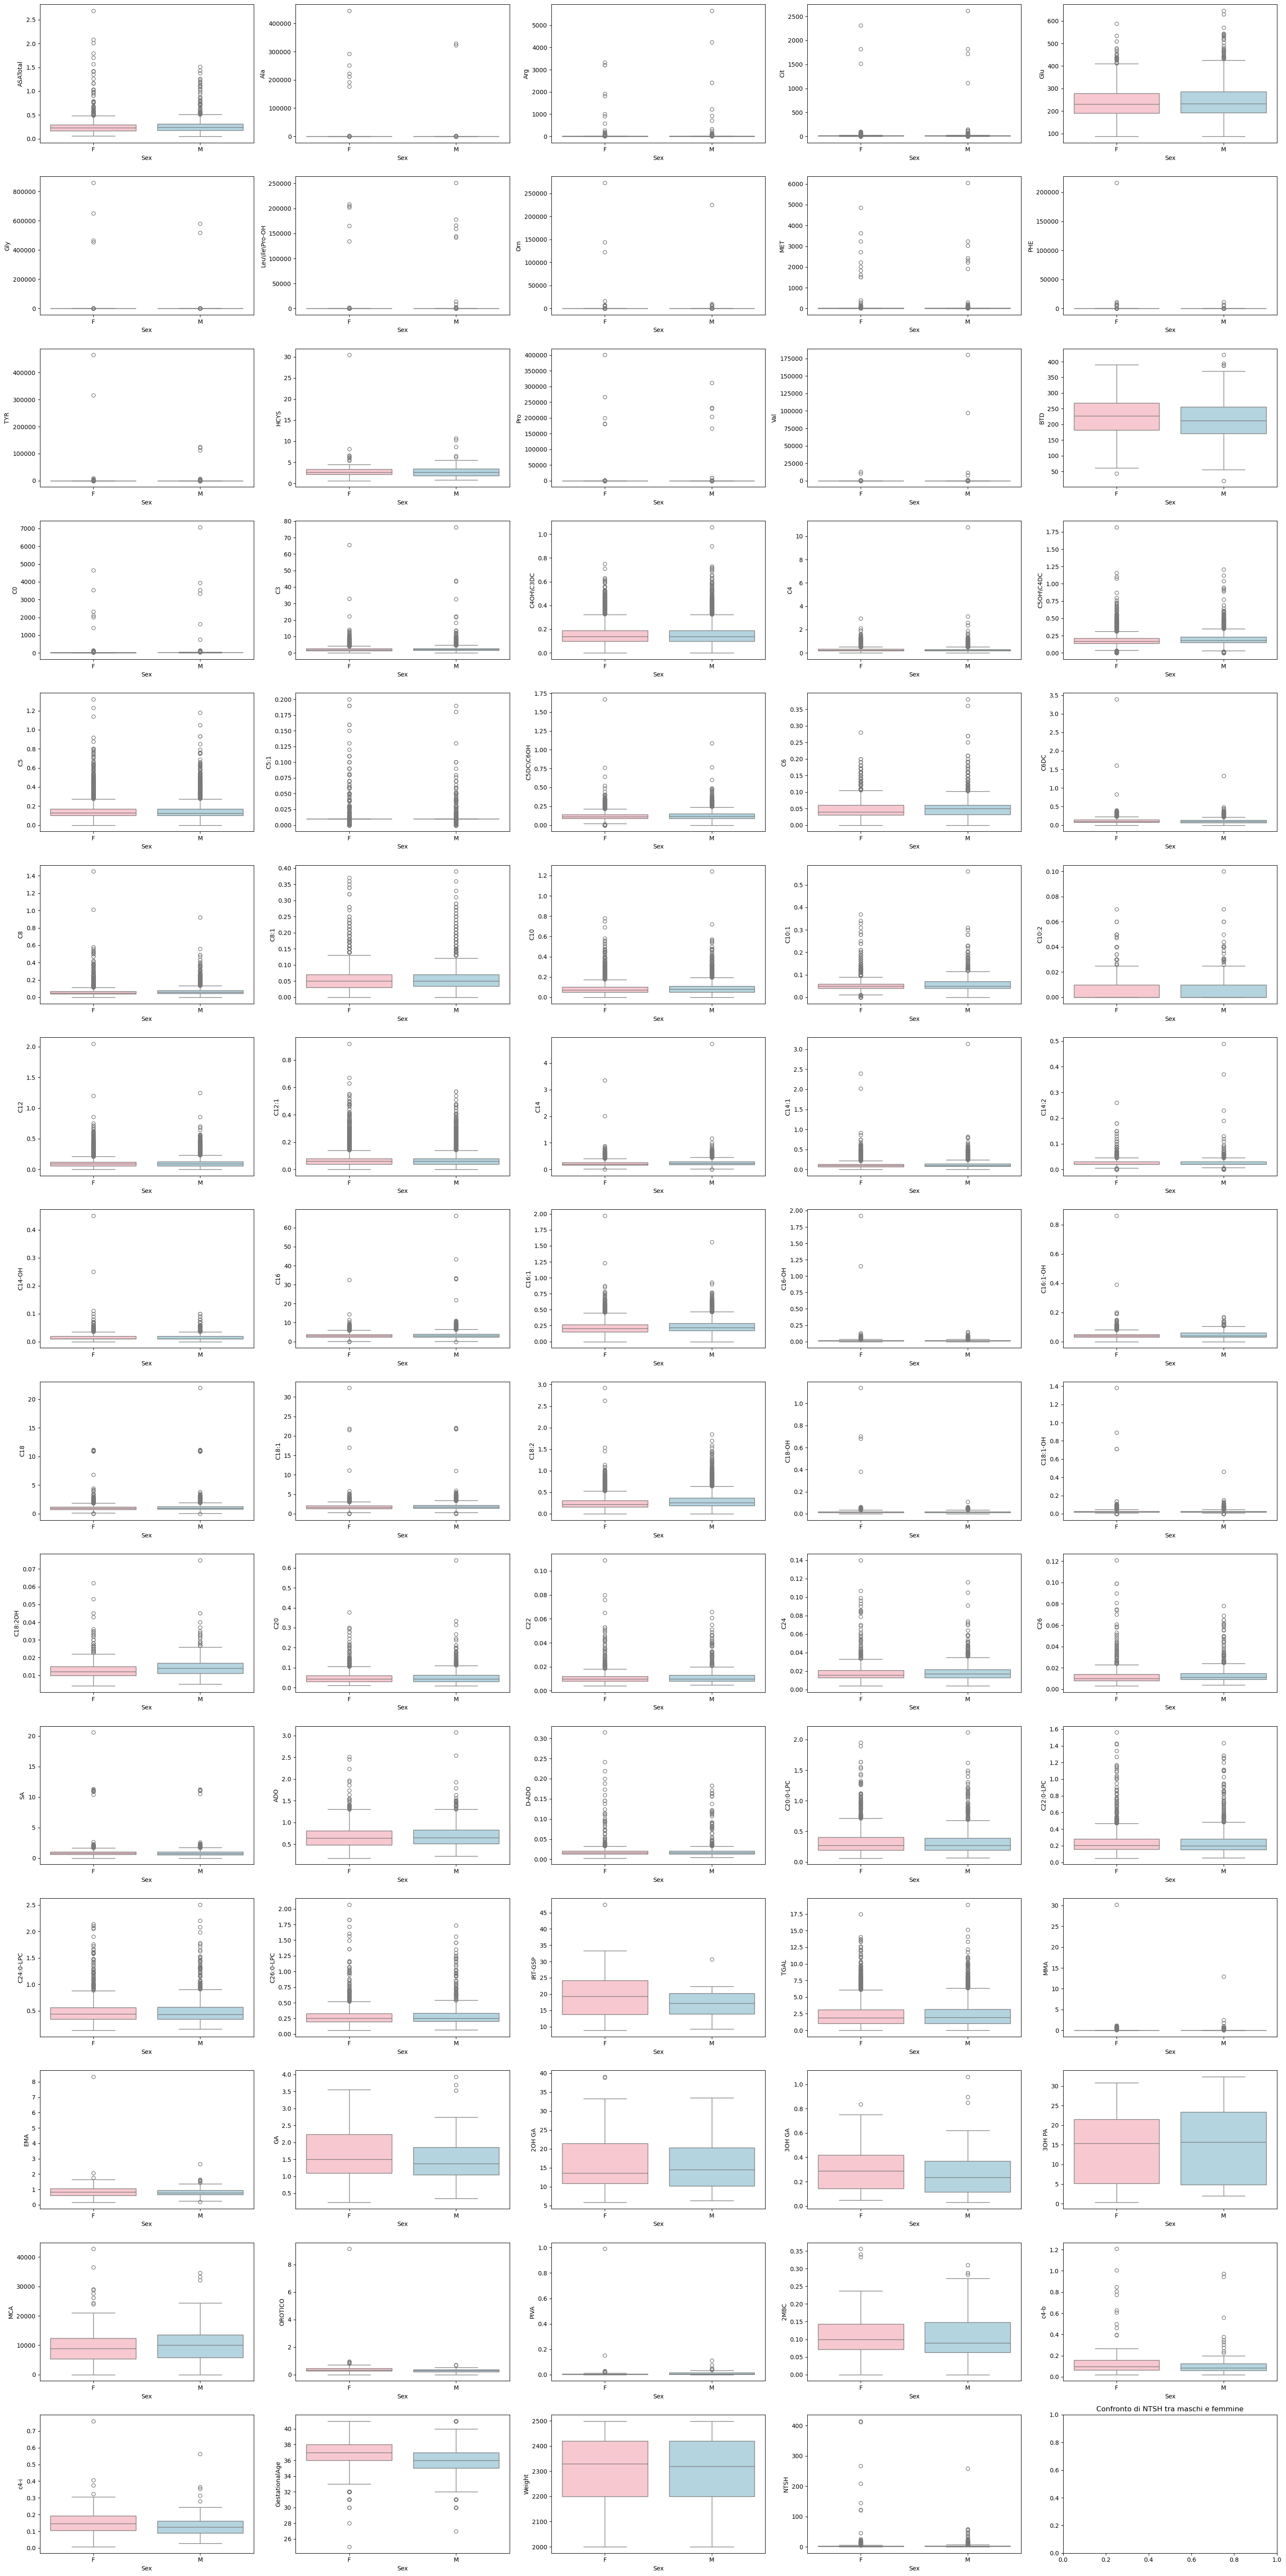

In [145]:
j = 0
i = 0
fig, axes = plt.subplots(15, 5, figsize=(30, 60)) 

piccolip = piccoli.to_pandas()

for col in colonne_numeriche: 
    
    sns.boxplot(x='Sex', y= col, ax = axes[i,j], data=piccolip, hue='Sex', palette={'M': 'lightblue', 'F': 'pink'})  
    plt.title(f'Confronto di {col} tra maschi e femmine')
    #plt.show()
    #plt.xticks(fontsize=20)  
    #plt.yticks(fontsize=40)
    j = j+1
    if j % 5 == 0:
        i = i + 1
        j = 0    

plt.savefig('F_M_medi.png')
plt.tight_layout()

#### Babies over 2,5kg 

In [147]:
ciccioni = babies_def2.filter(pl.col('Weight') >= 2500)
ciccioni.shape

(698051, 100)

In [148]:
statistics_c2 = ciccioni[colonne_numeriche].describe()
iq99 = ciccioni.select(pl.col(colonne_numeriche).quantile(0.99))
iq01 = ciccioni.select(pl.col(colonne_numeriche).quantile(0.01))
kurt = ciccioni.select(pl.col(colonne_numeriche).kurtosis())
ske = ciccioni.select(pl.col(colonne_numeriche).skew())
more_stat = pl.concat([iq99, iq01, kurt, ske])
new_col = pl.Series("new_col",['99%','1%','Kurtosis','Skewness'])
more_stat = more_stat.with_columns([new_col])
more_stat = more_stat.rename({"new_col": "statistic"})
more_stat = more_stat.select(["statistic"] + [col for col in more_stat.columns if col != "statistic"])

statistics_c2 = pl.concat([statistics_c2, more_stat])
statistics_c2 = statistics_c2.with_columns([pl.col(col).round(3).alias(col) if col != "statistic" else pl.col(col)for col in more_stat.columns])
statistics_c2

statistic,ASATotal,Ala,Arg,Cit,Glu,Gly,Leu\Ile\Pro-OH,Orn,MET,PHE,TYR,HCYS,Pro,Val,BTD,C0,C3,C4OH\C3DC,C4,C5OH\C4DC,C5,C5:1,C5DC\C6OH,C6,C6DC,C8,C8:1,C10,C10:1,C10:2,C12,C12:1,C14,C14:1,C14:2,C14-OH,C16,C16:1,C16-OH,C16:1-OH,C18,C18:1,C18:2,C18-OH,C18:1-OH,C18:2OH,C20,C22,C24,C26,SA,ADO,D-ADO,C20:0-LPC,C22:0-LPC,C24:0-LPC,C26:0-LPC,IRT-GSP,TGAL,MMA,EMA,GA,2OH GA,3OH GA,3OH PA,MCA,OROTICO,PIVA,2MBC,c4-b,c4-i,GestationalAge,Weight,NTSH
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",46727.0,697938.0,697938.0,697938.0,46727.0,697938.0,697938.0,697938.0,697938.0,697940.0,697940.0,2563.0,697938.0,697938.0,218707.0,697938.0,697938.0,697937.0,697938.0,697937.0,697938.0,697938.0,697937.0,697938.0,697938.0,697938.0,697938.0,697938.0,697938.0,697938.0,697938.0,697938.0,697938.0,697938.0,697938.0,697938.0,697938.0,697938.0,697938.0,697938.0,697938.0,697938.0,697937.0,697938.0,697937.0,46727.0,46727.0,46727.0,46727.0,46727.0,697939.0,46727.0,46727.0,46727.0,46727.0,46727.0,46727.0,882.0,218508.0,657060.0,2563.0,2563.0,2563.0,2563.0,2563.0,2563.0,2563.0,2563.0,2563.0,2563.0,2563.0,698051.0,698051.0,698044.0
"""null_count""",651324.0,113.0,113.0,113.0,651324.0,113.0,113.0,113.0,113.0,111.0,111.0,695488.0,113.0,113.0,479344.0,113.0,113.0,114.0,113.0,114.0,113.0,113.0,114.0,113.0,113.0,113.0,113.0,113.0,113.0,113.0,113.0,113.0,113.0,113.0,113.0,113.0,113.0,113.0,113.0,113.0,113.0,113.0,114.0,113.0,114.0,651324.0,651324.0,651324.0,651324.0,651324.0,112.0,651324.0,651324.0,651324.0,651324.0,651324.0,651324.0,697169.0,479543.0,40991.0,695488.0,695488.0,695488.0,695488.0,695488.0,695488.0,695488.0,695488.0,695488.0,695488.0,695488.0,0.0,0.0,7.0
"""mean""",0.287,341.934,9.885,14.299,249.736,545.912,182.503,125.166,19.679,59.661,110.837,3.231,224.157,509.427,245.461,19.022,2.105,0.2,0.247,0.207,0.111,0.009,0.131,0.047,0.127,0.064,0.033,0.096,0.048,0.003,0.126,0.093,0.241,0.133,0.02,0.018,3.716,0.257,0.024,0.045,1.091,1.721,0.162,0.016,0.026,0.011,0.05,0.011,0.019,0.012,0.805,0.588,0.019,0.286,0.241,0.518,0.296,19.743,2.005,0.004,1.212,1.73,17.859,0.369,14.612,9807.239,0.448,0.006,0.08,0.184,0.216,39.111,3318.163,2.487
"""std""",0.175,11038.257,21.311,28.637,1167.583,7610.805,2739.295,1853.378,35.664,627.636,1764.938,2.474,3036.979,285179.617,56.596,38.822,2.021,0.089,0.137,0.092,0.064,0.007,0.05,0.023,0.056,0.1,0.021,0.052,0.019,0.005,0.069,0.056,0.087,0.081,0.012,0.01,1.379,0.092,0.011,0.015,0.417,0.625,0.084,0.007,0.01,0.004,0.03,0.006,0.009,0.008,0.391,0.223,0.017,0.192,0.155,0.264,0.172,10.68,2.015,0.85,1.602,1.527,8.845,0.338,8.964,9817.433,1.334,0.031,0.043,0.239,3.328,1.288,403.123,3.824
"""min""",0.036,0.0,0.0,0.0,23.454,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.403,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001,0.003,0.002,0.001,0.001,0.0,0.062,0.0,0.024,0.017,0.04,0.028,0.0,0.0,0.0,0.0,0.0,0.0,-0.789,0.202,0.0,0.0,0.0,0.0,0.0,0.0,23.0,2500.0,0.0
"""25%""",0.188,205.73,4.77,10.48,198.576,339.09,118.89,77.01,15.28,47.64,69.3,2.177,149.98,108.36,205.955,12.89,1.46,0.14,0.17,0.16,0.08,0.006,0.1,0.03,0.09,0.04,0.02,0.06,0.04,0.0,0.08,0.06,0.18,0.09,0.01,0.01,2.84,0.19,0.02,0.03,0.83,1.34,0.11,0.01,0.02,0.008,0.032,0.008,0.013,0.008,0.57,0.434,0.013,0.169,0.154,0.362,0.204,12.514,0.844,0.0,0.653,1.175,10.802,0.158,5.313,4743.558,0.246,0.001,0.053,0.062,0.081,38.0,3030.0,1.356
"""50%""",0.249,248.34,8.077,13.26,235.234,413.81,139.76,97.33,18.69,54.69,86.511,2.82,174.78,129.64,249.976,16.89,1.92,0.19,0.22,0.2,0.1,0.01,0.12,0.04,0.12,0.06,0.03,0.084,0.05,0.0,0.11,0.08,0.23,0.12,0.02,0.02,3.54,0.246,0.02,0.04,1.03,1.64,0.14,0.017,0.02,0.01,0.042,0.01,0.017,0.01,0.78,0.56,0.016,0.23,0.199,0.454,0.256,17.314,1.557,0.0

In [149]:
header = statistics_c2["statistic"].to_list()

cicci_stat = statistics_c2.transpose(include_header=True)

cicci_stat.columns = ['Name'] + header
cicci_stat[1:]

piudue = cicci_stat['Name','null_count','mean','std', 'min', '25%', '50%', '75%', 'max', '99%', '1%', 'Kurtosis']

In [150]:
statistics_c2_pandas = piudue.to_pandas()
# Esporta come tabella LaTeX
statistiche_piu2500 = statistics_c2_pandas.to_latex(index=False)

# Salva la tabella LaTeX in un file .tex
with open("superduemezzo_table.tex", "w") as f:
    f.write(statistiche_piu2500)

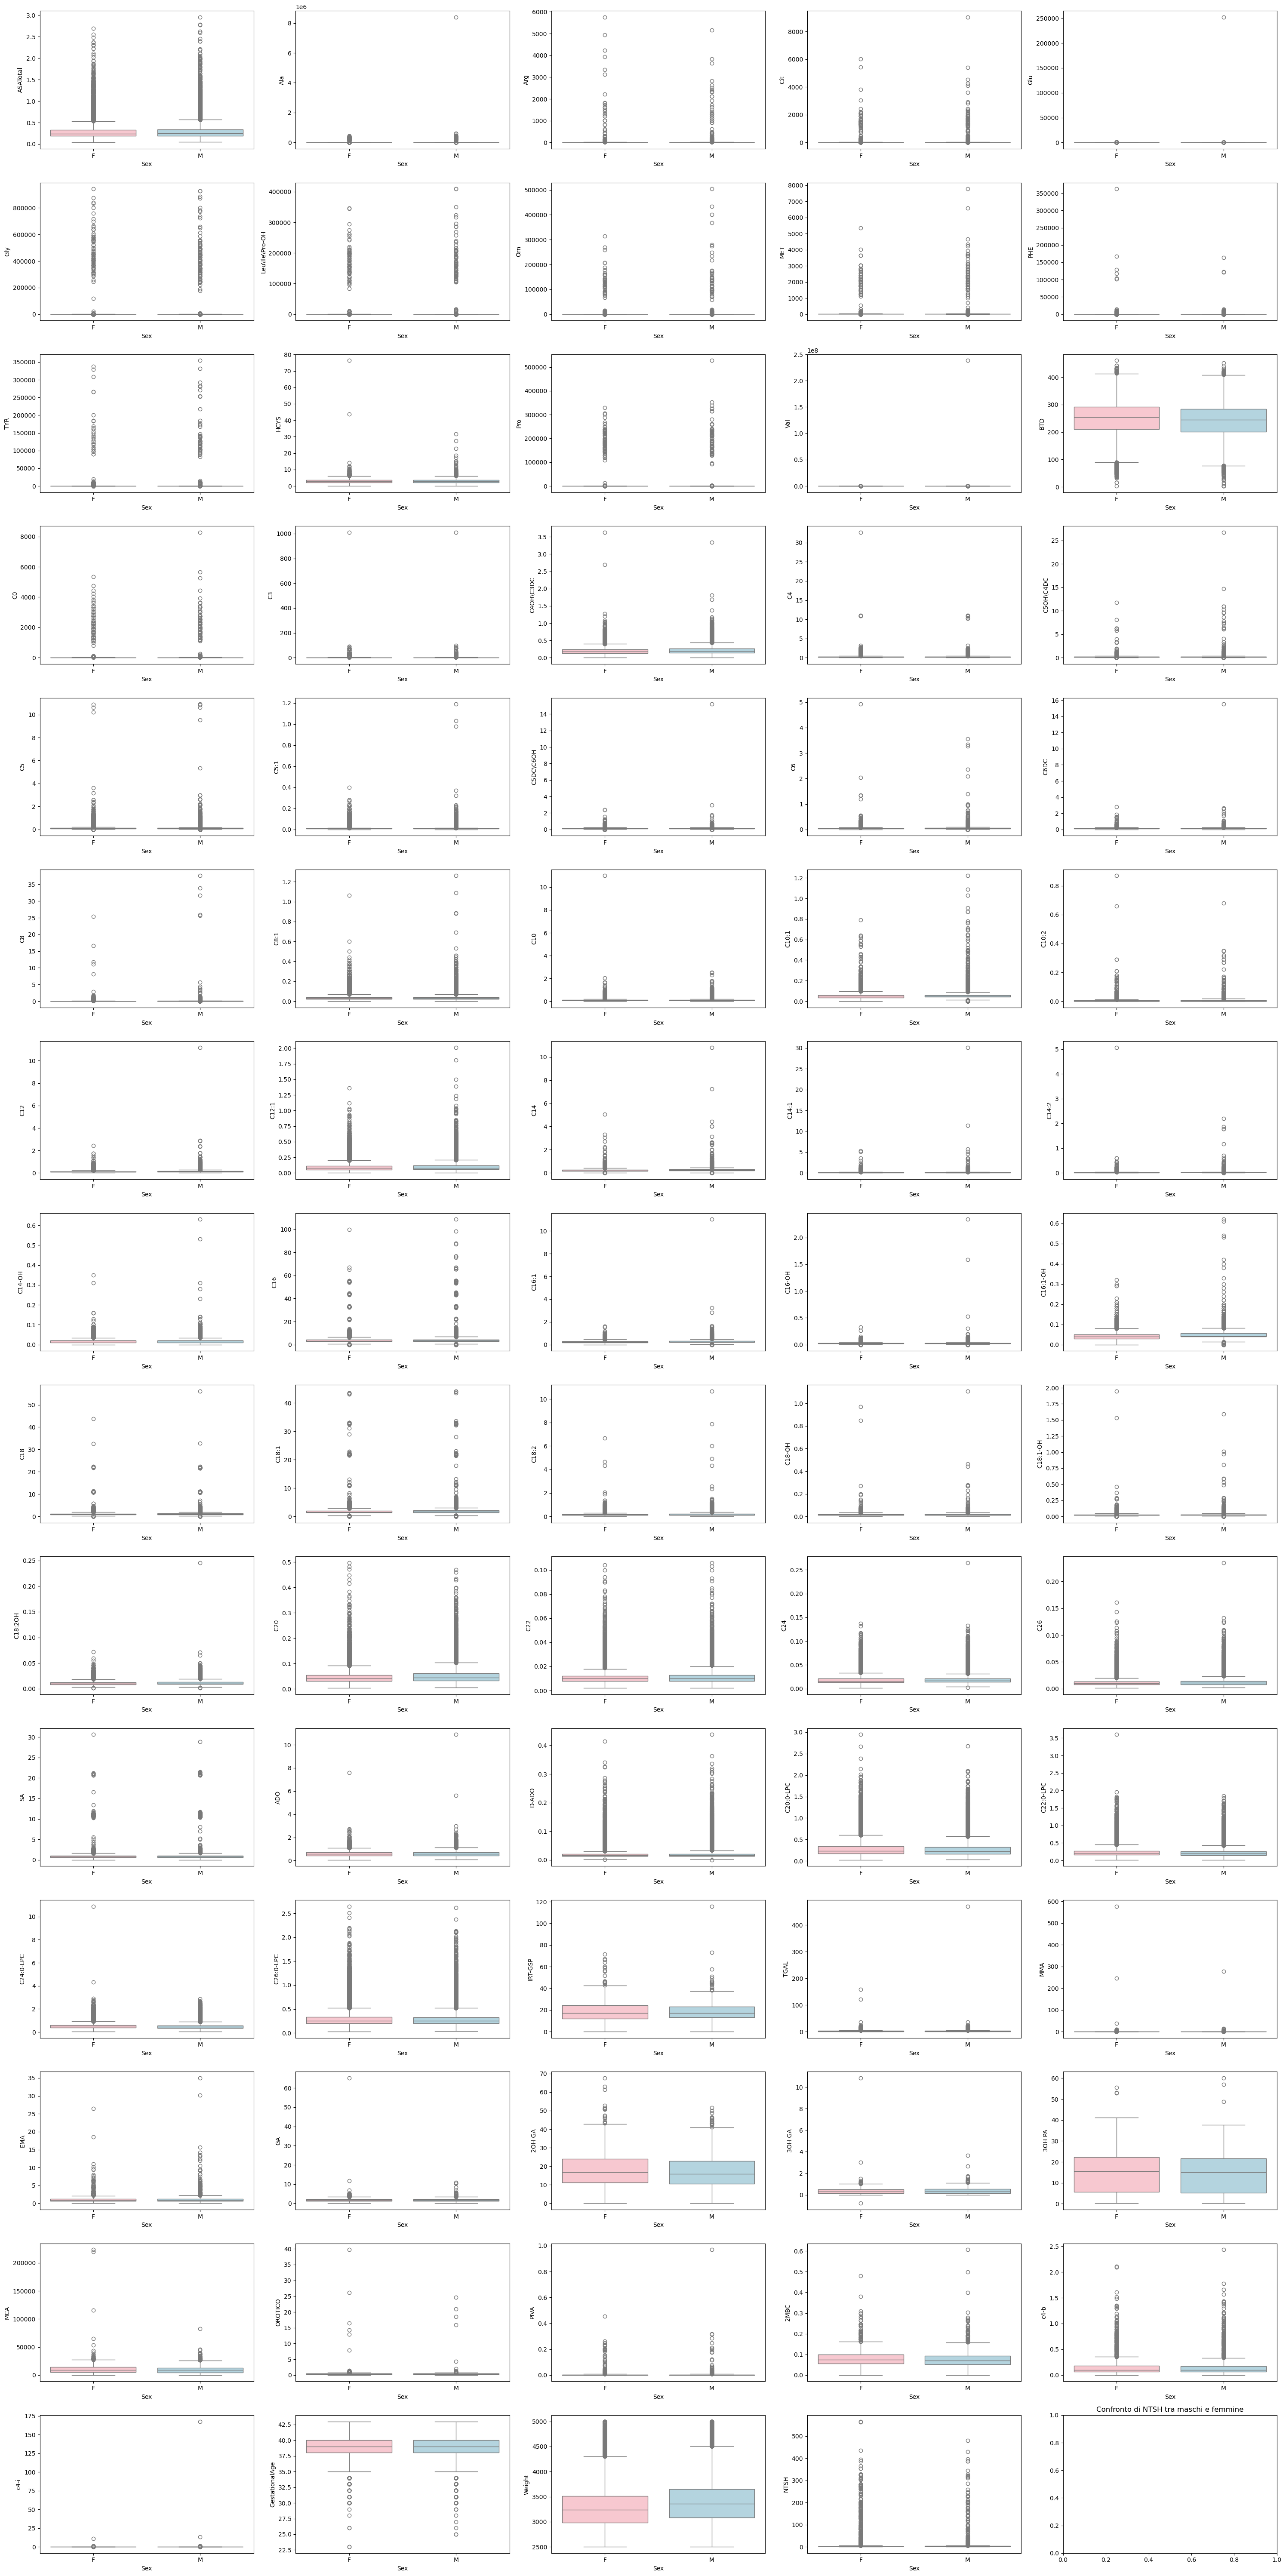

In [151]:
j = 0
i = 0
fig, axes = plt.subplots(15, 5, figsize=(30, 60)) 

ciccionip = ciccioni.to_pandas()

for col in colonne_numeriche: 
    
    sns.boxplot(x='Sex', y= col, ax = axes[i,j], data=ciccionip, hue='Sex', palette={'M': 'lightblue', 'F': 'pink'})  
    plt.title(f'Confronto di {col} tra maschi e femmine')
    #plt.show()
    #plt.xticks(fontsize=20)  
    #plt.yticks(fontsize=40)
    j = j+1
    if j % 5 == 0:
        i = i + 1
        j = 0    

plt.savefig('F_M_grandi.png')
plt.tight_layout()

### Distribution comparison

In [310]:
n1 = extra_piccoli.filter(pl.col('Diagnosis') != 'HEALTHY').shape[0]

In [312]:
n2 = piccoli_pic.filter(pl.col('Diagnosis') != 'HEALTHY').shape[0]

In [314]:
n3 = piccoli.filter(pl.col('Diagnosis') != 'HEALTHY').shape[0]

In [316]:
n4 = ciccioni.filter(pl.col('Diagnosis') != 'HEALTHY').shape[0]

In [318]:
p1 = round((n1/extra_piccoli.shape[0]) * 100, 2)
p2 = round((n2/piccoli_pic.shape[0]) * 100, 2)
p3 = round((n3/piccoli.shape[0]) * 100, 2) 
p4 = round((n4/ciccioni.shape[0]) * 100, 2)

In [320]:
data = {
    'Weight': ['< 1500', '1500 - 2000', ' 2000 - 2500', ' > 2500'],
    'Size': [extra_piccoli.shape[0], piccoli_pic.shape[0], piccoli.shape[0], ciccioni.shape[0]],
    'Positives': [n1, n2, n3, n4],
    'Percentage': [p1, p2, p3, p4]
}

# Creiamo il DataFrame
dati = pd.DataFrame(data)

In [322]:
dati.to_csv('dati.csv', index=False)

In [324]:
dati

,Weight,Size,Positives,Percentage
0,< 1500,5966,5,0.08
1,1500 - 2000,9172,0,0.00
2,2000 - 2500,35527,14,0.04
3,> 2500,698051,179,0.03


In [160]:
babies.shape

(791752, 102)

#### **Nice Table**

In [166]:
from tabulate import tabulate

# Creazione di un DataFrame Polars
data = {
    'Weight': ['> 2500','2500-2000', '2000-1500', '1500 >'],
    'Size': [ciccioni.shape[0], piccoli.shape[0], piccoli_pic.shape[0], extra_piccoli.shape[0]]
}

df = pl.DataFrame(data)

# Converti Polars DataFrame in Pandas DataFrame per usare tabulate
df_pandas = df.to_pandas()

# Visualizza la tabella con il formato 'grid'
print(tabulate(df_pandas, headers='keys', tablefmt='grid', showindex=False))


+-----------+--------+
| Weight    |   Size |
+===========+========+
| > 2500    | 698051 |
+-----------+--------+
| 2500-2000 |  35527 |
+-----------+--------+
| 2000-1500 |   9172 |
+-----------+--------+
| 1500 >    |   5966 |
+-----------+--------+
